## My summaries

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import yaml

base_path = f"results/wind_both_extendable_renewable"

# Input files
with open(f"{base_path}/configs/config.base_s_1___2050.yaml") as f:
    pypsa_config = yaml.safe_load(f)


n = pypsa.Network(f"{base_path}/networks/base_s_1___2050.nc")

# Plotting settings
tech_colors = pypsa_config["plotting"]["tech_colors"]
nice_names = pypsa_config["plotting"]["nice_names"]

In [ ]:
def smart_legend(
    ax_or_fig,
    handles,
    labels=None,
    threshold=8,
    max_label_length=15,
    use_fig_legend=False,
    **legend_kwargs
):
    """
    Create a legend that automatically switches between right-side and table layout.
    
    Parameters:
    - ax_or_fig: matplotlib axis or figure object
    - handles: list of legend handles (patches, lines, etc.)
    - labels: optional list of labels (if None, extracted from handles)
    - threshold: number of items above which to use table layout (default 8)
    - max_label_length: approximate max length of label text to determine columns (default 15)
    - use_fig_legend: if True, use fig.legend() instead of ax.legend()
    - **legend_kwargs: additional kwargs passed to legend()
    
    Returns:
    - legend: the created legend object
    
    Note: When using table layout (>threshold items), the legend is placed at the bottom
    of the plot area (loc='lower center'), not outside the axes. This ensures compatibility
    with tight_layout() and prevents dimension errors.
    """
    if labels is None:
        labels = [h.get_label() for h in handles]
    
    n_items = len(handles)
    
    # Determine if we should use table layout
    if n_items <= threshold:
        # Normal legend to the right
        if use_fig_legend:
            fig = ax_or_fig
            default_kwargs = {'loc': 'center left', 'bbox_to_anchor': (1, 0.5)}
        else:
            ax = ax_or_fig
            default_kwargs = {'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
        
        # Merge with user kwargs (user kwargs take precedence)
        final_kwargs = {**default_kwargs, **legend_kwargs}
        
        if use_fig_legend:
            return ax_or_fig.legend(handles, labels, **final_kwargs)
        else:
            return ax_or_fig.legend(handles=handles, labels=labels, **final_kwargs)
    else:
        # Table layout - place at bottom of plot area (inside axes)
        # Calculate number of columns based on longest label
        max_len = max(len(str(label)) for label in labels) if labels else 10
        
        # Heuristic: aim for ~50-70 characters total width
        # Adjust columns based on label length
        if max_len <= max_label_length:
            ncol = min(4, max(2, n_items // 3))  # 2-4 columns
        elif max_len <= max_label_length * 1.5:
            ncol = min(3, max(2, n_items // 4))  # 2-3 columns
        else:
            ncol = 2  # Long labels get only 2 columns
        
        # Create legend at bottom inside the plot area
        # This avoids issues with tight_layout()
        if use_fig_legend:
            fig = ax_or_fig
            default_kwargs = {
                'loc': 'lower center',
                'bbox_to_anchor': (0.5, 0.0),
                'bbox_transform': fig.transFigure,
                'ncol': ncol,
                'frameon': True,
                'fancybox': False,
                'shadow': False,
            }
        else:
            ax = ax_or_fig
            # Place legend at bottom inside the axes - compatible with tight_layout
            default_kwargs = {
                'loc': 'lower center',
                'ncol': ncol,
                'frameon': True,
                'fancybox': False,
                'shadow': False,
            }
        
        # Merge with user kwargs
        final_kwargs = {**default_kwargs, **legend_kwargs}
        
        if use_fig_legend:
            return ax_or_fig.legend(handles, labels, **final_kwargs)
        else:
            return ax_or_fig.legend(handles=handles, labels=labels, **final_kwargs)


def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    legend_threshold=8,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters:
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - legend_threshold: number of legend items above which to use table layout below plot (default 8)
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0
        
        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]

            series = series.dropna()
            
            # Split into positive and negative values
            pos_series = series.sort_values(ascending=False) # removed: [series > 0]
            neg_series = series.sort_values(ascending=True)  # Sort ascending for leftward stacking # removed: [series < 0]
            
            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}
            
            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()
                
                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)
                
                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)
            
            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())
                
                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)
                
                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)
            
            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )
            
            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    else:
        # Single bar (original behavior)
        legend_handles = {}
        _plot_single_bar(
            data,
            ax,
            0,
            tech_colors,
            nice_names,
            annotate_thresh,
            bar_height,
            legend_handles,
            annotate_decimals,
        )
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)


def enforce_common_xlim(axes, data_list, pad_fraction=0.05):
    """
    Enforce a common x-axis limit across multiple axes when sharex=True.

    Parameters:
    - axes: array of matplotlib axes
    - data_list: list of pandas Series OR dicts of Series corresponding to each axis
    - pad_fraction: fraction of max range to add as padding (default 0.05)

    Returns:
    - tuple: (xmin, xmax) the computed common limits
    """
    # Flatten data: convert dicts to concatenated Series
    all_series = []
    for data in data_list:
        if isinstance(data, dict):
            # Concatenate all Series in the dict
            all_series.append(pd.concat(data.values()))
        else:
            # Already a Series (including MultiIndex)
            all_series.append(data)

    # Calculate max positive and negative values across all data
    max_pos = max((s[s > 0].sum() if (s > 0).any() else 0) for s in all_series)
    max_neg = max((abs(s[s < 0].sum()) if (s < 0).any() else 0) for s in all_series)

    # Add padding
    pad = pad_fraction * max(max_pos, max_neg, 1e-12)
    xmin = -(max_neg + pad)
    xmax = max_pos + pad

    # Apply to all axes
    for a in axes:
        a.set_xlim(xmin, xmax)

    return xmin, xmax


def plot_comparison_barh(
    data,
    ax,
    *,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_bracket_width=0.15,
    group_label_font_size=9,
    marker_size=8,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters:
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_bracket_width: horizontal offset for group brackets (as fraction of max value)
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Determine which columns to use
    if lower_col is None:
        lower_col = data.columns[0]
    if upper_col is None:
        upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    # Calculate max and min values
    max_val = data[[lower_col, upper_col]].max().max()
    min_val = data[[lower_col, upper_col]].min().min()
    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero
    
    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Plot bars
    for item, y, label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    lower_val = group_data.loc[item, lower_col]
                    upper_val = group_data.loc[item, upper_col]

                    # Plot upper bound as full opaque bar
                    if pd.notna(upper_val):
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                    # Plot lower bound as 'x' marker
                    if pd.notna(lower_val):
                        ax.plot(
                            lower_val,
                            y,
                            marker='x',
                            color='black',
                            markersize=marker_size,
                            markeredgewidth=1.5,
                            linestyle='',
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [label for _, _, label in y_positions]
    
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)
    
    # Set x-axis limits
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05
    
    ax.set_xlim(x_min, x_max)
    
    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()
    
    # Get the position of the leftmost edge of the widest y-tick label
    # This will be our reference point for the brackets
    try:
        # Get bounding boxes of y-tick labels in display coordinates
        renderer = ax.figure.canvas.get_renderer()
        bboxes = [label.get_window_extent(renderer=renderer) for label in ax.get_yticklabels()]
        
        if bboxes:
            # Find the leftmost edge among all labels (in display coordinates)
            leftmost_display = min([bbox.x0 for bbox in bboxes])
            
            # Convert from display to data coordinates
            # We need to transform a point at the left edge of the labels
            inv = ax.transData.inverted()
            # Use the y-coordinate from the middle of the plot
            y_middle_display = sum([bbox.y0 + bbox.y1 for bbox in bboxes]) / (2 * len(bboxes))
            leftmost_x = inv.transform([[leftmost_display, y_middle_display]])[0][0]
        else:
            leftmost_x = x_min
    except Exception:
        # Fallback if we can't get label positions
        leftmost_x = x_min
    
    # Position brackets just to the left of the leftmost label edge
    bracket_offset = (x_max - x_min) * 0.06  # Small offset from labels
    x_bracket_pos = leftmost_x - bracket_offset

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [x_bracket_pos, x_bracket_pos],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Draw horizontal ticks at ends
            tick_width = (x_max - x_min) * 0.01
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                x_bracket_pos - tick_width * 1.5,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        mpatches.Patch(facecolor="gray", label=upper_col),
        Line2D([0], [0], marker='x', color='black', label=lower_col,
               markersize=marker_size, markeredgewidth=1.5, linestyle=''),
    ]
    ax.legend(handles=legend_elements, loc="lower right")

In [ ]:
# Example: Override threshold to see table legend with current data
fig, ax = plt.subplots(figsize=(10, 2))

stacked_barh_signed(
    eb / 1e6,  # TWh
    ax,
    tech_colors=tech_colors,
    nice_names=nice_names,
    y_label="Total Demand",
    group_labels=group_labels,
    legend_threshold=5,  # Lower threshold to trigger table layout
)

ax.set_title("Energy balance (with table legend)")
ax.set_xlabel("Energy [TWh]")
plt.tight_layout()
plt.show()

### Energy balance

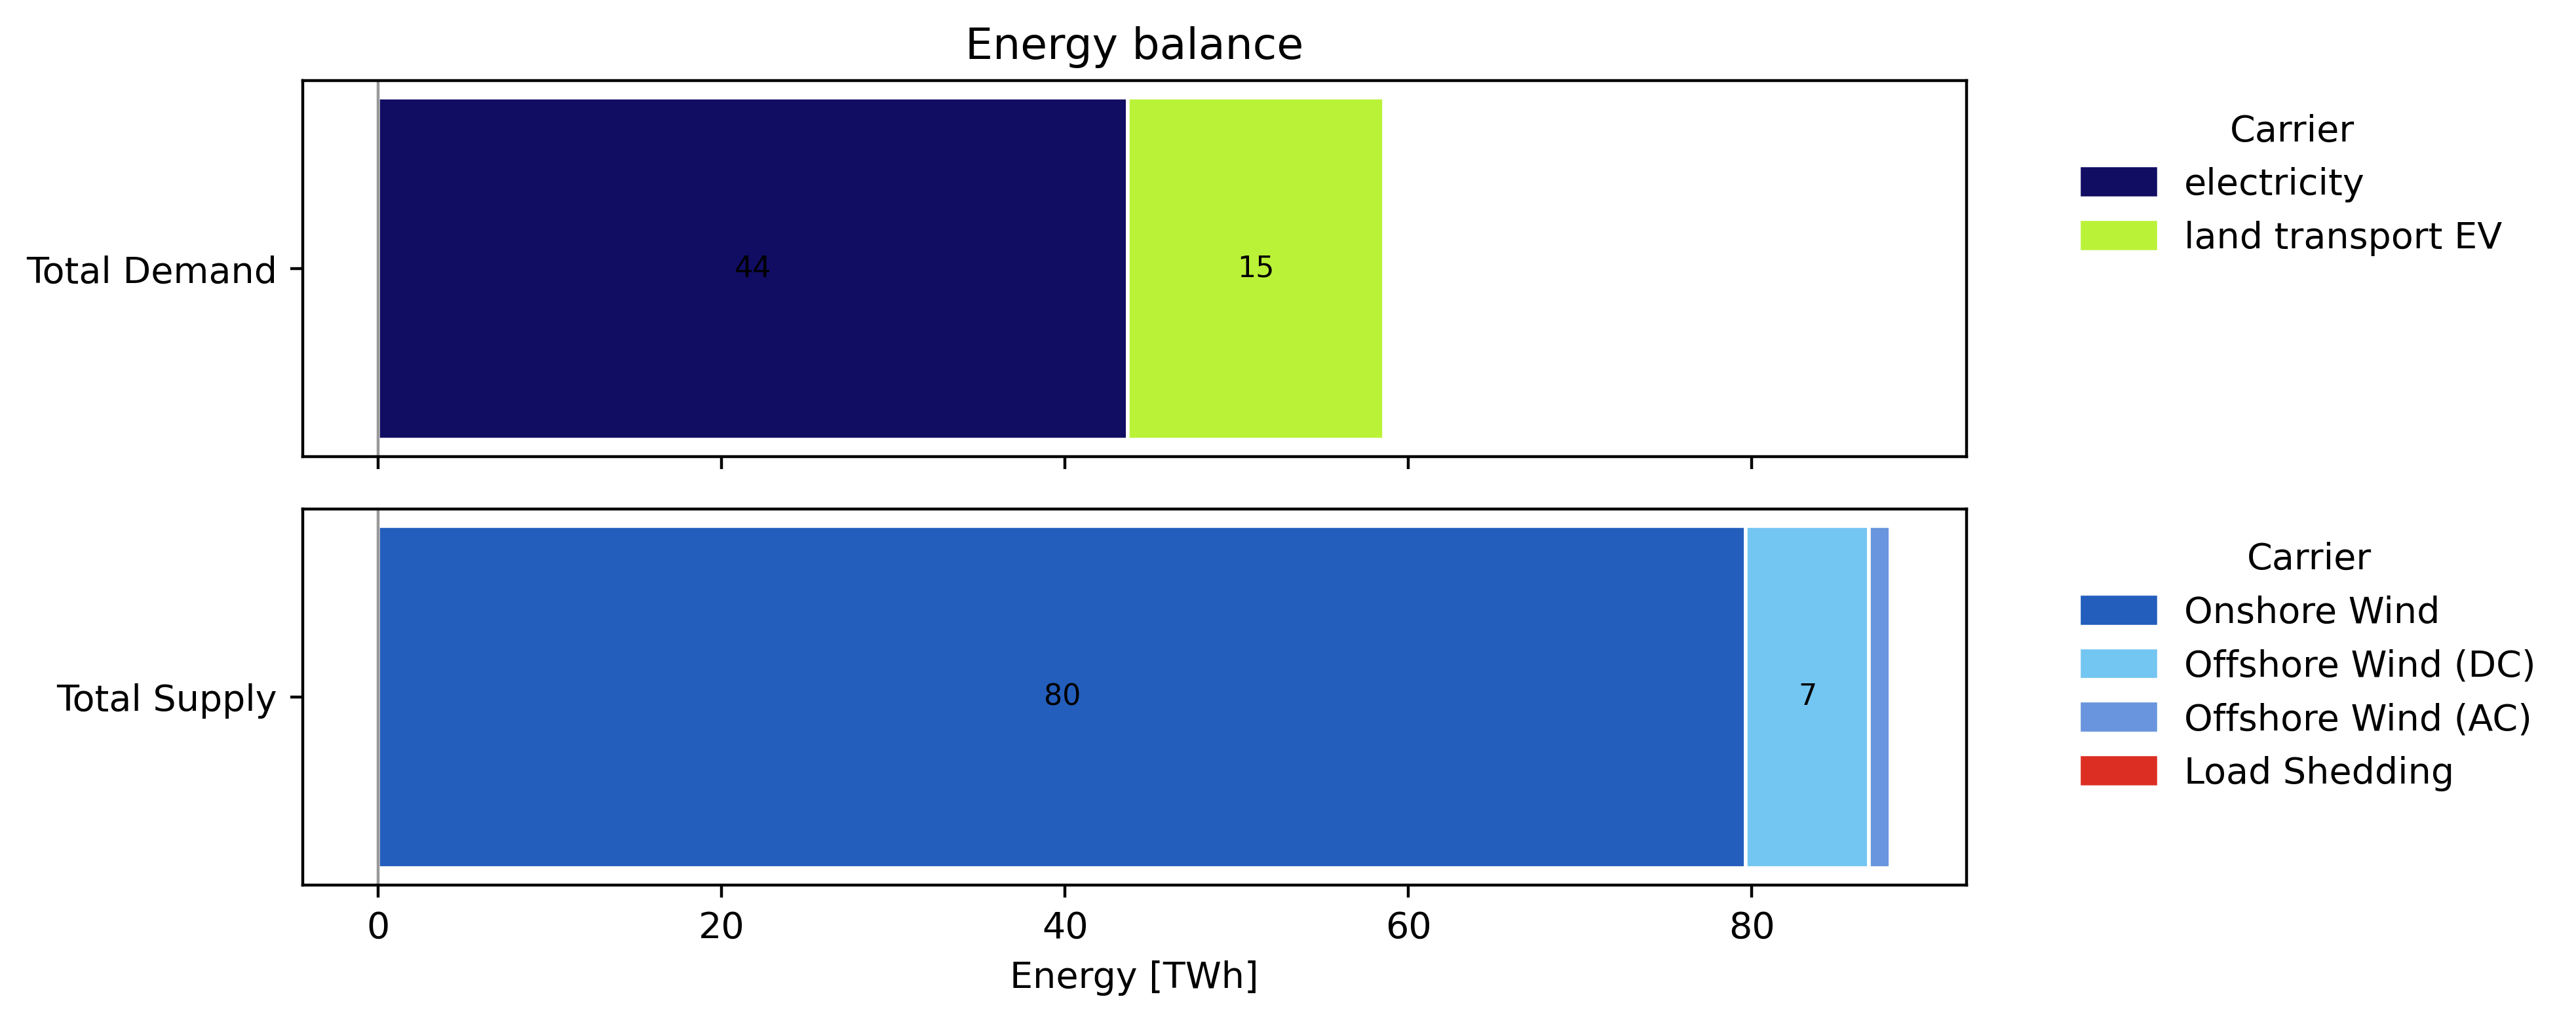

Total positive energy balance: 88.09 TWh
Total negative energy balance: -58.57 TWh
Total energy balance: 29.52 TWh


In [ ]:
snapshots = pd.DatetimeIndex(n.snapshots)
dt = snapshots[1] - snapshots[0]
time_delta = float(dt / pd.Timedelta(hours=1))

# calculate total demand by carrier
demand_by_carrier = n.loads_t["p"].T.groupby(n.loads["carrier"]).sum().T.sum().sort_values() * time_delta  # MWh

# calculate total supply by carrier
supply_by_carrier = n.generators_t["p"].T.groupby(n.generators["carrier"]).sum().T.sum().sort_values() * time_delta  # MWh

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

stacked_barh_signed(
    demand_by_carrier / 1e6,  # TWh
    ax[0],
    tech_colors=tech_colors,
    nice_names=nice_names,
    y_label="Total Demand",
)

stacked_barh_signed(
    supply_by_carrier / 1e6,  # TWh
    ax[1],
    tech_colors=tech_colors,
    nice_names=nice_names,
    y_label="Total Supply",
)

# Enforce common x-limit across both plots
enforce_common_xlim(ax, [demand_by_carrier / 1e6, supply_by_carrier / 1e6])

ax[0].set_title("Energy balance")
ax[-1].set_xlabel("Energy [TWh]")
plt.tight_layout()
plt.show()

# print total energy balance for generators and loads
include = ["Generator", "Load"]
stats = n.statistics()
energy_flows = stats[stats.index.isin(include, level=0)]
pos_energy = energy_flows.loc[energy_flows["Energy Balance"] > 0]["Energy Balance"]
neg_energy = energy_flows.loc[energy_flows["Energy Balance"] < 0]["Energy Balance"]
print(f"Total positive energy balance: {sum(pos_energy) / 1e6:.2f} TWh")
print(f"Total negative energy balance: {sum(neg_energy) / 1e6:.2f} TWh")
print(f"Total energy balance: {energy_flows['Energy Balance'].sum() / 1e6:.2f} TWh")


### Capacity

NameError: name 'capacity_e' is not defined

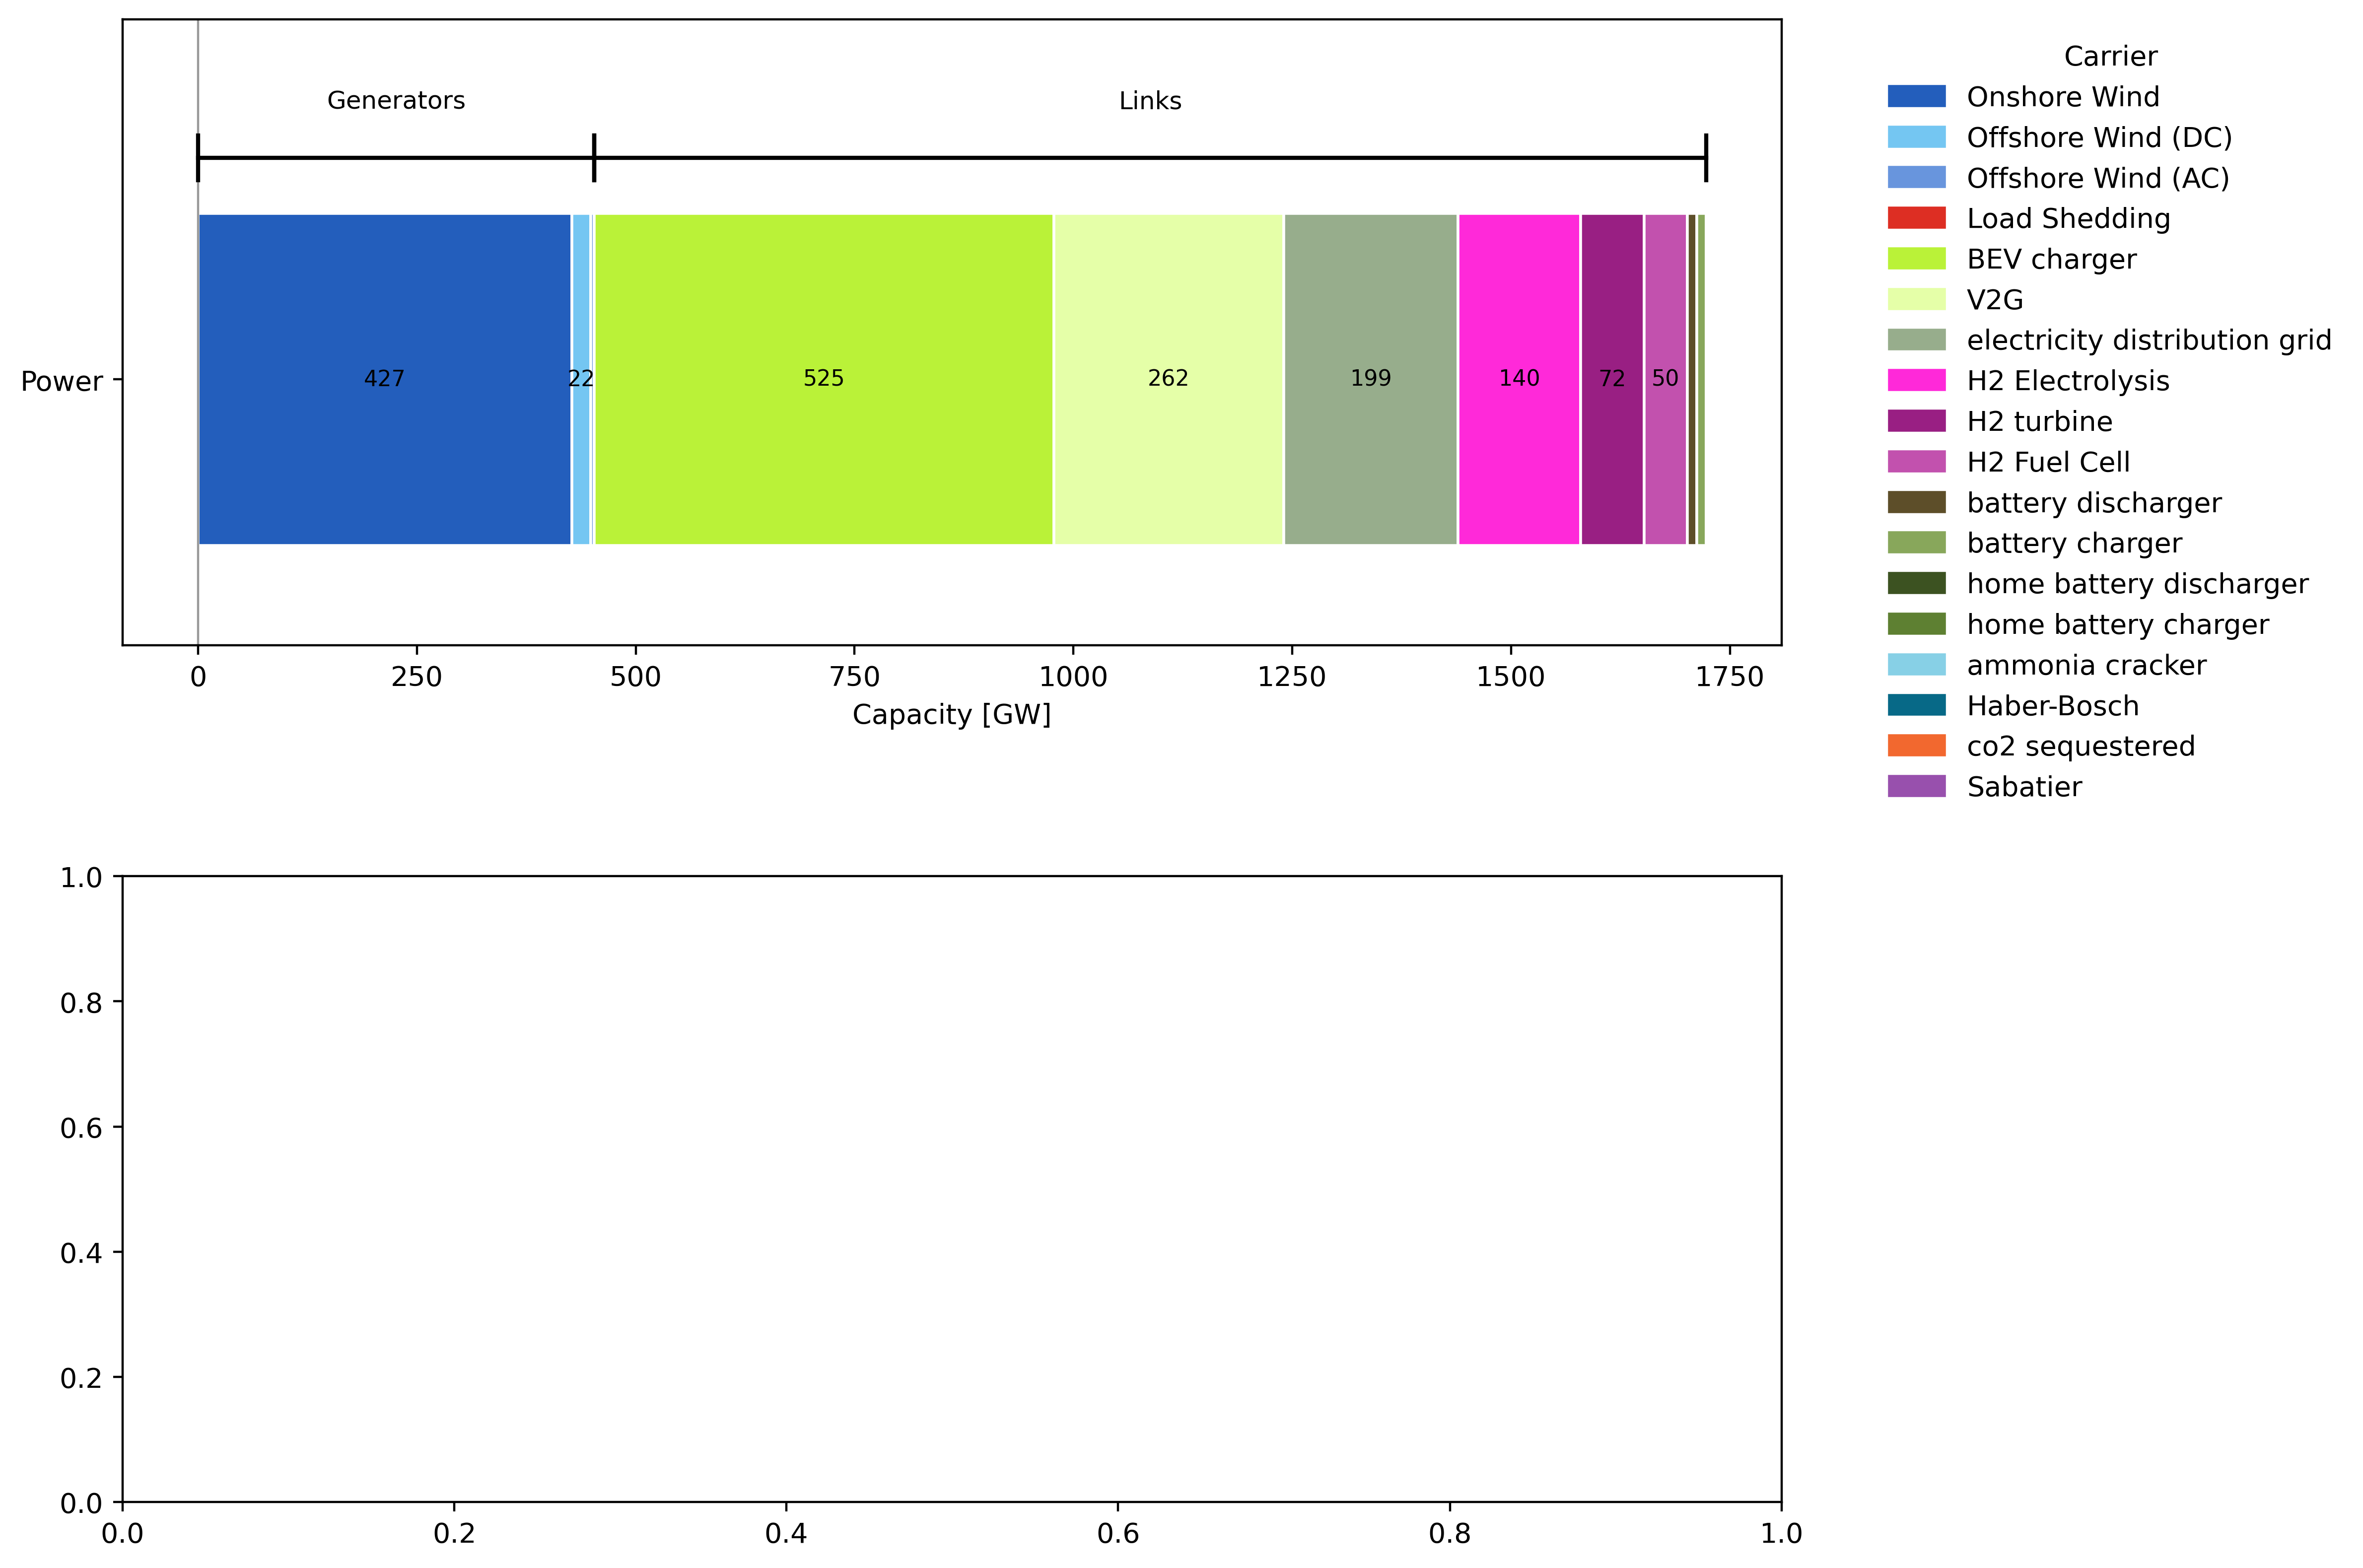

In [ ]:
components_p = ["generators", "links", "storage_units"]
capacity_p = {}

for comp in components_p:
    comp_df = getattr(n, comp)
    if comp_df.size == 0:
        continue
    capacity_p[comp] = comp_df.groupby(comp_df.carrier).sum().p_nom_opt  # MW

# components_e = ["storage_units", "stores"]
# capacity_e = {}

# for comp in components_e:
#     comp_df = getattr(n, comp)
#     if comp_df.size == 0:
#         continue
#     capacity_e[comp] = comp_df.groupby(comp_df.carrier).sum().e_nom_opt  # MWh

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

group_labels = {
    "generators": "Generators",
    "links": "Links",
    "storage_units": "Storage Units",
}
capacity_p_GW = {k: v / 1e3 for k, v in capacity_p.items()}  # GW

stacked_barh_signed(
    capacity_p_GW,  # GW
    ax[0],
    tech_colors=tech_colors,
    nice_names=nice_names,
    y_label="Power",
    group_labels=group_labels,
    annotate_thresh=0.02,
    group_bracket_height=0.1,
    group_label_font_size=9,
    bar_height=0.6
)

ax[0].set_xlabel("Capacity [GW]")

group_labels = {"storage_units": "Storage Units", "stores": "Stores"}
capacity_e_TWh = {k: v / 1e6 for k, v in capacity_e.items()}  # TWh

stacked_barh_signed(
    capacity_e_TWh,  # TWh
    ax[1],
    tech_colors=tech_colors,
    nice_names=nice_names,
    y_label="Energy",
    group_labels=group_labels,
    annotate_thresh=0.02,
    group_bracket_height=0.1,
    group_label_font_size=9,
    bar_height=0.6,
    annotate_decimals=2,
)

ax[1].set_xlabel("Capacity [TWh]")
ax[0].set_title("Installed technology capacities")

plt.tight_layout()
plt.show()

### Energy throughput

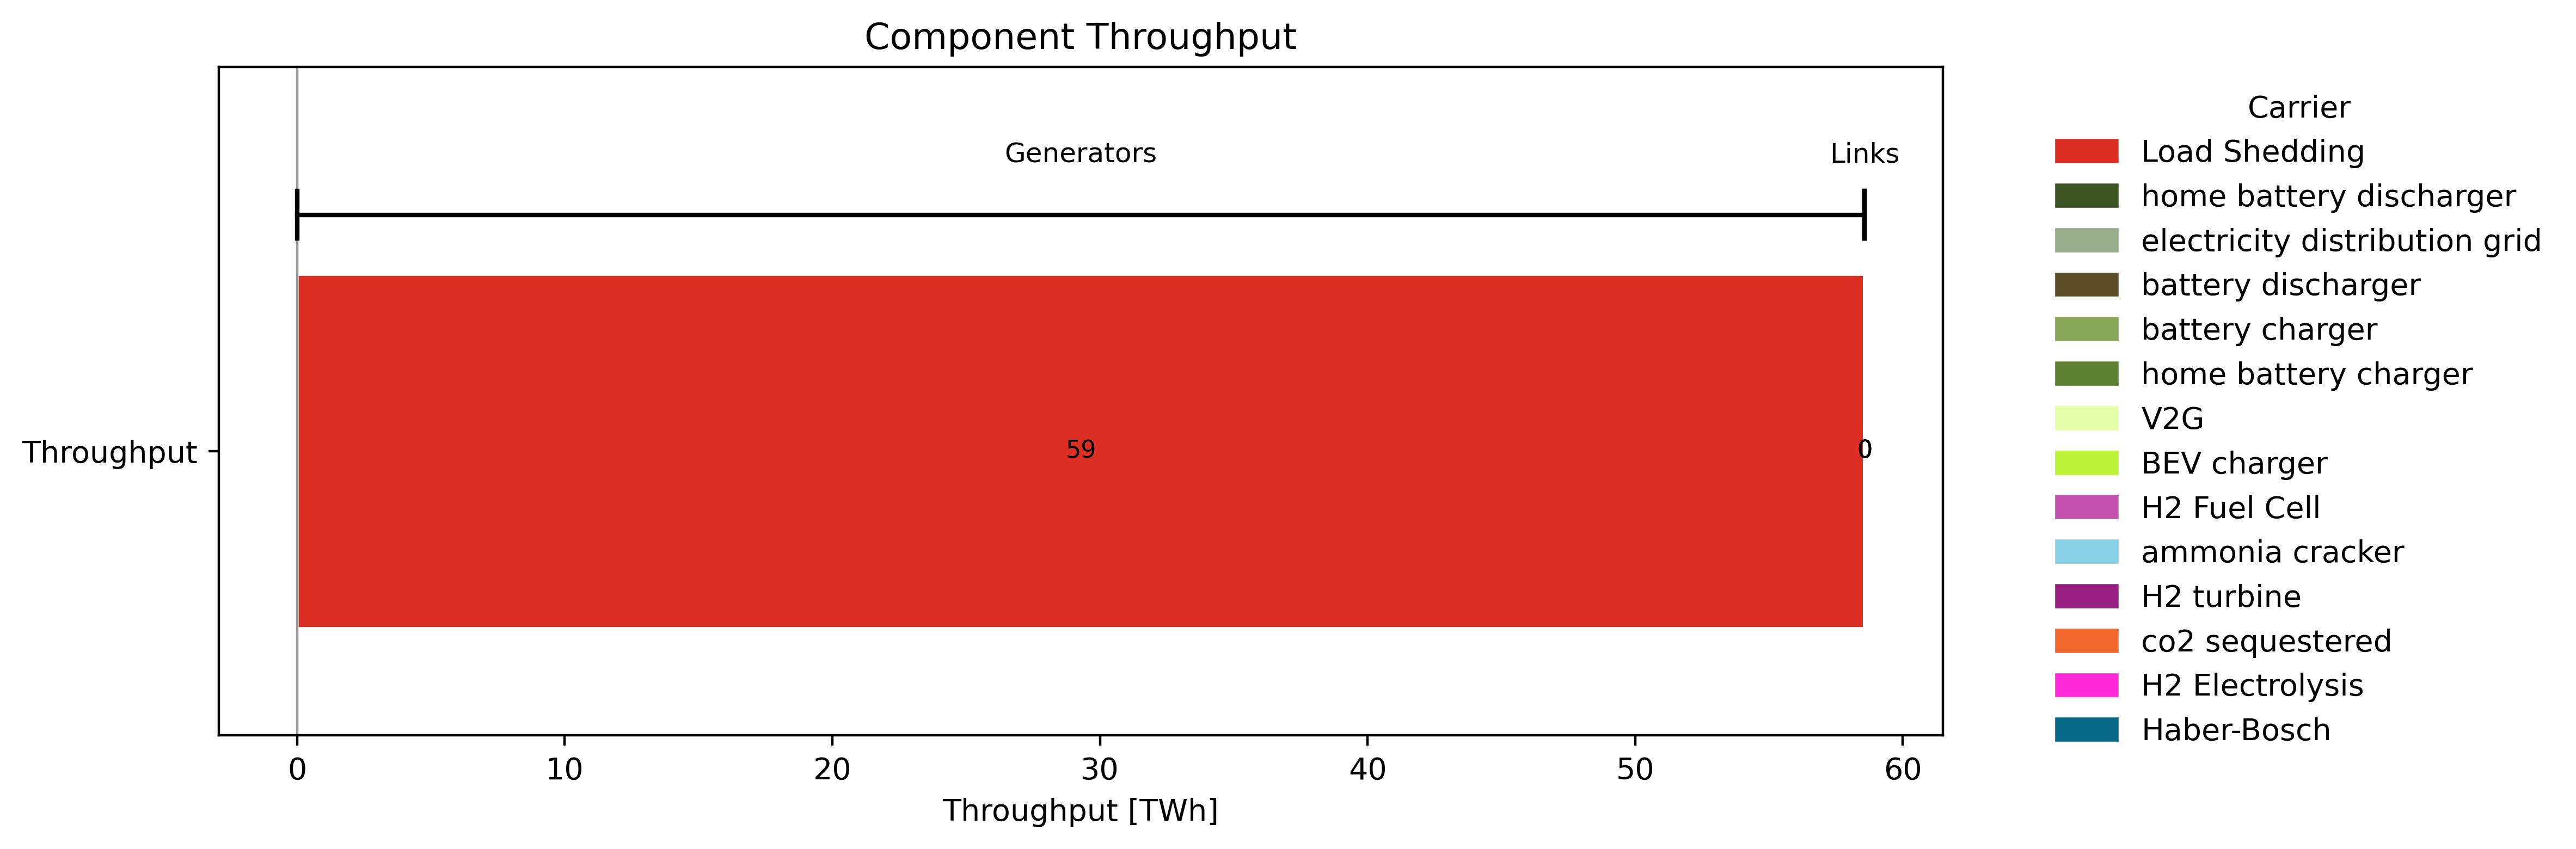

In [ ]:
components_t = ["generators_t", "links_t", "storage_units_t", "stores_t"]
throughput = {}

for comp in components_t:
    if comp == "links_t":
        comp_df = getattr(n, comp)["p0"]
    else:
        comp_df = getattr(n, comp)["p"]

    if comp_df.size == 0:
        continue

    energy_by_bus = comp_df.sum() * time_delta  # MWh
    bus_carrier = getattr(n, comp.replace("_t", ""))["carrier"]
    throughput[comp] = energy_by_bus.groupby(bus_carrier).sum()  # MWh

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

group_labels = {
    "generators_t": "Generators",
    "links_t": "Links",
    "storage_units_t": "Storage Units",
    "stores_t": "Stores",
}

throughput_TWh = {k: v / 1e6 for k, v in throughput.items()}

stacked_barh_signed(
    throughput_TWh,
    ax,
    tech_colors=tech_colors,
    nice_names=nice_names,
    y_label="Throughput",
    group_labels=group_labels,
    annotate_thresh=0.02,
    group_bracket_height=0.1,
    group_label_font_size=9,
    bar_height=0.6,
)

ax.set_xlabel("Throughput [TWh]")
ax.set_title("Component Throughput")
plt.tight_layout()
plt.show()

### Cost

In [ ]:
capex = {}
opex = {}

for comp in components_p:
    # generators, links, and storage units all have capex per MW installed and opex per MWh throughput
    if comp not in capacity_p:
        continue

    # capex
    capex_marginal_df = getattr(n, comp)  # €/MW
    capex_per_carrier = capex_marginal_df.groupby('carrier')['capital_cost'].agg(['max', 'nunique'])  # €/MW
    if comp == "links":
        exception = ["electricity distribution grid-reversed" in s for s in capex_marginal_df.index]
        new_value = capex_per_carrier.loc["electricity distribution grid", "max"]
        capex_marginal_df.loc[exception, "capital_cost"] = new_value
        capex_per_carrier.loc["electricity distribution grid", "nunique"] = 1

    assert (capex_per_carrier['nunique'] == 1).all(), "Some carriers have multiple capital costs!"
    capex[comp] = capacity_p[comp] * capex_per_carrier['max']  # €

    # opex
    opex_marginal_df = getattr(n, comp)  # €/MWh
    opex_per_carrier = opex_marginal_df.groupby('carrier')['marginal_cost'].agg(['max', 'nunique'])
    assert (opex_per_carrier['nunique'] == 1).all(), "Some carriers have multiple opex costs!"
    opex[comp] = throughput[f"{comp}_t"] * opex_per_carrier['max']  # €


for comp in ["stores"]:
    # capex
    capex_marginal_df = getattr(n, comp)  # €/MWh
    capex_per_carrier = capex_marginal_df.groupby('carrier')['capital_cost'].agg(['max', 'nunique'])  # €/MWh
    assert (capex_per_carrier['nunique'] == 1).all(), "Some carriers have multiple capital costs!"
    capex[comp] = capacity_e[comp] * capex_per_carrier['max']  # €

    # opex
    opex_marginal_df = getattr(n, comp)
    opex_per_carrier = opex_marginal_df.groupby('carrier')['marginal_cost'].agg(['max', 'nunique'])
    assert (opex_per_carrier['nunique'] == 1).all(), "Some carriers have multiple opex costs!"

    opex[comp] = throughput[f"{comp}_t"] * opex_per_carrier['max']  # €

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

group_labels = {
    "generators": "Generators",
    "links": "Links",
    "storage_units": "Storage units",
    "stores": "Stores"
}

capex_Beur = {k: v / 1e9 for k, v in capex.items()}

stacked_barh_signed(
    capex_Beur,
    ax[0],
    tech_colors=tech_colors,
    nice_names=nice_names,
    group_labels=group_labels,
    y_label="CapEx",
    annotate_decimals=1,
)

opex_Beur = {k: v / 1e9 for k, v in opex.items()}

stacked_barh_signed(
    opex_Beur,
    ax[1],
    tech_colors=tech_colors,
    nice_names=nice_names,
    group_labels=group_labels,
    y_label="OpEx",
    annotate_decimals=1,
)

# Enforce common x-limit across both plots
enforce_common_xlim(ax, [capex_Beur, opex_Beur])

ax[0].set_xlabel("Cost [B€]")
ax[1].set_xlabel("Cost [B€]")
ax[0].set_title("Component Costs")
plt.tight_layout()
plt.show()

total_capex = sum(series.sum() for series in capex.values())  # €
total_opex = sum(series.sum() for series in opex.values())  # €
total_cost = total_capex + total_opex  # €
print(f"Total CAPEX: {total_capex / 1e9:.2f} B€")
print(f"Total OPEX: {total_opex / 1e9:.2f} B€")
print(f"Total cost: {total_cost / 1e9:.2f} B€")

AssertionError: Some carriers have multiple opex costs!

## Network properties

In [ ]:
n[sample]

PyPSA Network ''
----------------
Components:
 - Bus: 11
 - Carrier: 31
 - Generator: 18
 - GlobalConstraint: 2
 - Link: 11
 - Load: 2
 - Store: 7
Snapshots: 8760

In [ ]:
n[sample].statistics()

Optimal Capacity  Installed Capacity  \
Generator Load shedding                      0.000000e+00               0.000   
          Offshore Wind (AC)                 4.179646e+03               0.000   
          Offshore Wind (DC)                 2.175411e+04               0.000   
          Onshore Wind                       1.046334e+05               0.000   
          Solar                              0.000000e+00               0.000   
          gas                                1.375171e+05               0.000   
          solar rooftop                      1.605885e+05               0.000   
          solar-hsat                         1.495159e+05               0.000   
Link      BEV charger                        5.248757e+05          524875.747   
          Combined-Cycle Gas                 4.456624e+04               0.000   
          Open-Cycle Gas                     9.295082e+04               0.000   
          battery charger                    6.251617e+04               0.000   
          battery discharger                 6.380530e+04               0.000   
          co2 sequestered                    0.000000e+00               0.000   
          electricity distribution grid      1.767897e+05               0.000   
          home battery charger               0.000000e+00               0.000   
          home battery discharger            0.000000e+00               0.000   
Load      electricity                        0.000000e+00               0.000   
          land transport EV                  0.000000e+00               0.000   
Store     Battery Storage                    3.586375e+05               0.000   
          EV battery                         1.192899e+06         1192899.425   
          co2                                4.262754e+07               0.000   
          co2 sequestered                    0.000000e+00               0.000   
          co2 stored                         0.000000e+00               0.000   
          gas                                1.000000e-05               0.000   
          home battery                       0.000000e+00               0.000   

                                               Supply    Withdrawal  \
Generator Load shedding                  0.000000e+00  0.000000e+00   
          Offshore Wind (AC)             1.517152e+07  0.000000e+00   
          Offshore Wind (DC)             9.549628e+07  0.000000e+00   
          Onshore Wind                   1.725568e+08  0.000000e+00   
          Solar                          7.000000e-05  0.000000e+00   
          gas                            2.152906e+08  0.000000e+00   
          solar rooftop                  1.539953e+08  0.000000e+00   
          solar-hsat                     1.583418e+08  0.000000e+00   
Link      BEV charger                    0.000000e+00  1.865011e+08   
          Combined-Cycle Gas             0.000000e+00  1.468070e+08   
          Open-Cycle Gas                 0.000000e+00  6.848357e+07   
          battery charger                0.000000e+00  2.213913e+08   
          battery discharger             0.000000e+00  2.169183e+08   
          co2 sequestered                0.000000e+00  0.000000e+00   
          electricity distribution grid  0.000000e+00  7.950958e+08   
          home battery charger           0.000000e+00  7.000000e-05   
          home battery discharger        0.000000e+00  7.000000e-05   
Load      electricity                    0.000000e+00  4.938842e+08   
          land transport EV              0.000000e+00  1.678510e+08   
Store     Battery Storage                4.563601e+07  4.563601e+07   
          EV battery                     6.298484e+07  6.298484e+07   
          co2                            0.000000e+00  4.262754e+07   
          co2 sequestered                0.000000e+00  0.000000e+00   
          co2 stored                     0.000000e+00  0.000000e+00   
          gas                            5.600000e-04  5.600000e-04   
       

In [ ]:
# useful for statistics on attributes
n[sample].component_attrs.keys()

/var/folders/cd/3symzw7d0833vd8qj4shbrl80000gp/T/ipykernel_87183/1597056803.py:2: DeprecatedWarning:

component_attrs is deprecated as of 1.0rc1 and will be removed in 2.0. Use `self.components.<component>.defaults` instead.



dict_keys(['Bus', 'Carrier', 'Generator', 'Load', 'Link', 'Store', 'LineType', 'TransformerType', 'GlobalConstraint'])

In [ ]:
dir(n[sample])

['__abstractmethods__',
 '__add__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_components',
 '_crs',
 '_empty_components',
 '_export_to_exporter',
 '_import_components_from_df',
 '_import_from_importer',
 '_import_series_from_df',
 '_index_names',
 '_investment_periods_data',
 '_linearized_uc',
 '_meta',
 '_model',
 '_multi_invest',
 '_name',
 '_objective',
 '_objective_constant',
 '_pypsa_version',
 '_read_in_default_standard_types',
 '_risk_preference',
 '_scenarios_data',
 '_snapshots_data',
 'add',
 'adjacency_matrix',
 'all_components',
 'branch_components',
 'branches',
 'bus_

## Questions

### Are heat pumps hiding generation?

In [ ]:
import scipy
import xarray as xr

ds = xr.open_dataset("../pypsa-eur/resources/shared/cop_profiles_base_s_1_2050.nc")

In [ ]:
n[sample].links.loc[n[sample].links["carrier"].isin(
    ["urban central air heat pump", "rural air heat pump", "rural ground heat pump", "urban decentral air heat pump"]
)]

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus2,efficiency2,efficiency3,reversed,length_original
name,,,,,,,,,,,,,,,,,,,,,


### How does load shedding work?

In [ ]:
generator_mask = n[sample].generators["carrier"].isin(["load"])
n[sample].generators[generator_mask]

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
DE0 0 load,DE0 0,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,3.260489e-14
EU load,EU,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,-0.000000e+00
co2 atmosphere load,co2 atmosphere,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,-0.000000e+00
DE0 0 co2 stored load,DE0 0 co2 stored,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,7.585064e-14
DE0 0 co2 sequestered load,DE0 0 co2 sequestered,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,6.325539e-14
EU gas load,EU gas,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,-0.000000e+00
DE0 0 H2 load,DE0 0 H2,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,-0.000000e+00
DE0 0 battery load,DE0 0 battery,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,3.253621e-14
DE0 0 EV battery load,DE0 0 EV battery,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,4.263256e-14


It seems that every bus has an associated "load" generator

/var/folders/cd/3symzw7d0833vd8qj4shbrl80000gp/T/ipykernel_87183/2694814423.py:15: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/cd/3symzw7d0833vd8qj4shbrl80000gp/T/ipykernel_87183/2694814423.py:21: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/cd/3symzw7d0833vd8qj4shbrl80000gp/T/ipykernel_87183/2694814423.py:27: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



(0.0, 518.5783714766874)

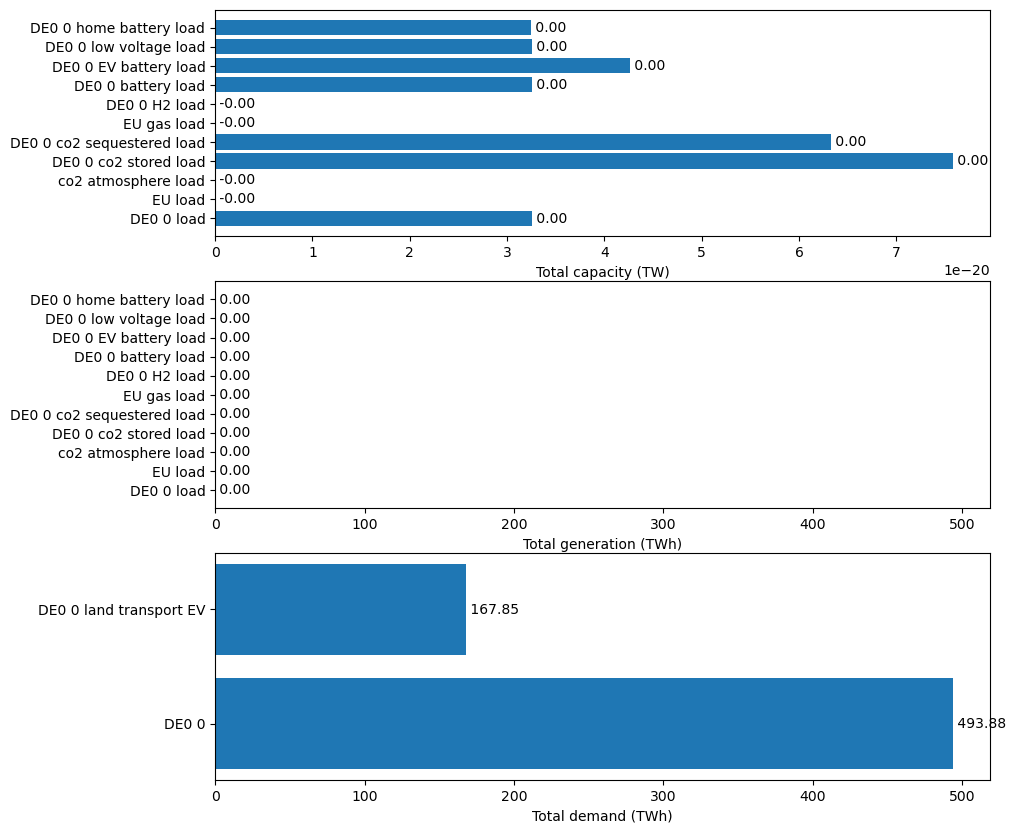

In [ ]:
loads_p_nom = n[sample].generators[generator_mask]["p_nom_opt"] / 1e6  # to TW
loads_p = n[sample].generators_t["p"].T.loc[generator_mask] / 1e3  # to GW
snapshots = pd.DatetimeIndex(n[sample].snapshots)
dt = snapshots[1] - snapshots[0]
time_delta = float(dt / pd.Timedelta(hours=1))
sum_loads_p = loads_p.sum(axis=1) * time_delta / 1e3  # to TWh
demands_types = n[sample].loads_t["p_set"].sum() * time_delta / 1e6  # to TWh

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

ax[0].barh(loads_p_nom.index, loads_p_nom)
ax[0].set_xlabel("Total capacity (TW)")
# add values to bars
for i in range(len(loads_p_nom)):
    ax[0].text(loads_p_nom[i], i, f" {loads_p_nom[i]:.2f}", va='center')

ax[1].barh(sum_loads_p.index, sum_loads_p)
ax[1].set_xlabel("Total generation (TWh)")
# add values to bars
for i in range(len(sum_loads_p)):
    ax[1].text(sum_loads_p[i], i, f" {sum_loads_p[i]:.2f}", va='center')

ax[2].barh(demands_types.index, demands_types)
ax[2].set_xlabel("Total demand (TWh)")
# add values to bars
for i in range(len(demands_types)):
    ax[2].text(demands_types[i], i, f" {demands_types[i]:.2f}", va='center')

# set subplots 1 and 2 to have same x-axis limits
max_limit = max(ax[1].get_xlim()[1], ax[2].get_xlim()[1])
ax[1].set_xlim(0, max_limit)
ax[2].set_xlim(0, max_limit)

(377400.0, 377568.0)

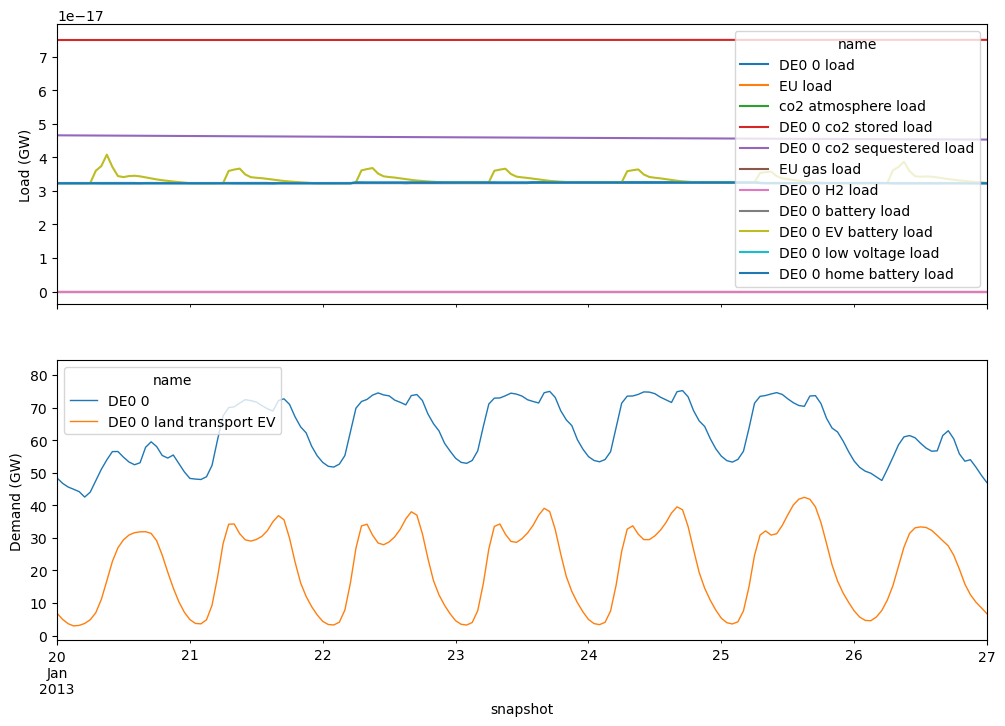

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

demands_p = n[sample].loads_t.p_set / 1e3  # GW
loads_p.T.plot(ax=ax[0])  # GW
ax[0].set_ylabel("Load (GW)")


demands_p.plot(ax=ax[1], linewidth=1, label="demand")
ax[1].set_ylabel("Demand (GW)")

ax[0].set_xlim("2013-01-20", "2013-01-27")

In [ ]:
n[sample].loads_t["p_set"]

name,DE0 0,DE0 0 land transport EV
snapshot,,
2013-01-01 00:00:00,37459.054940,4184.372576
2013-01-01 01:00:00,35946.494530,3180.678707
2013-01-01 02:00:00,34509.615440,2996.181572
2013-01-01 03:00:00,33977.714291,3782.843432
2013-01-01 04:00:00,33390.384605,7239.673171
...,...,...
2013-12-31 19:00:00,49002.054970,22655.842678
2013-12-31 20:00:00,47484.164895,16166.437118
2013-12-31 21:00:00,47714.406590,11964.630141


### Did the 90% condition work?
Yes! But what's going on with load shedding?

Wait - maybe I should've used all energy carriers when I calculated the total demand!?

In [ ]:
n[sample].generators["carrier"].isin(["load"])

name
DE0 0 0 onwind                False
DE0 0 0 offwind-ac            False
DE0 0 0 offwind-dc            False
DE0 0 0 solar-hsat            False
DE0 0 0 solar                 False
EU gas                        False
DE0 0 0 solar rooftop         False
DE0 0 load                     True
EU load                        True
co2 atmosphere load            True
DE0 0 co2 stored load          True
DE0 0 co2 sequestered load     True
EU gas load                    True
DE0 0 H2 load                  True
DE0 0 battery load             True
DE0 0 EV battery load          True
DE0 0 low voltage load         True
DE0 0 home battery load        True
Name: carrier, dtype: bool

In [ ]:
snapshots = pd.DatetimeIndex(n[sample].snapshots)
dt = snapshots[1] - snapshots[0]
time_delta = float(dt / pd.Timedelta(hours=1))

total_demand = n[sample].loads_t['p_set'].sum().sum() * time_delta  # MWh

base_techs = [
    "offwind-ac",
    "offwind-dc",
    "solar-hsat",
    "onwind",
    "solar",
    "solar rooftop",
]

# select generators in base_techs
generation = (
    n[sample]
    .generators_t["p"]
    .sum(axis=0)
    .loc[n[sample].generators["carrier"].isin(base_techs)]
    * time_delta
)  # MWh
base_gen = generation.sum()  # MWh

load_generators = n[sample].generators["carrier"].isin(["load"])
load_shedding = n[sample].generators_t["p"].sum()[load_generators].sum() * time_delta  # MWh

print(f"Total demand: {total_demand / 1e6} TWh")
print(f"Total generation from base system: {base_gen / 1e6} TWh")
print(f"Proportion: {base_gen / total_demand}")
print(f"Load shedding: {load_shedding / 1e6} TWh")
print(f"Shedding proportion: {load_shedding / total_demand}")

Total demand: 661.7351565830386 TWh
Total generation from base system: 595.5616409247365 TWh
Proportion: 0.9000000000000027
Load shedding: 2.414342853973503e-15 TWh
Shedding proportion: 3.648503226638732e-18


### Where is my gas generation going?

The function `add_generation` calls `add_carrier_buses`.
1. `add_carrier_buses` adds
   
    (a) the `carrier`, e.g., `gas`

    (b) a `store` for the `carrier` as `nodes + " Store"`, e.g., `CH0 0 gas Store`

    (c) if `sector.fossil_fuels` is `True`, also a `generator` as `nodes + suffix` 
    (where `suffix` is `""`)

2. `add_generation` adds a link of `nodes + " " + generator` e.g., `CH0 0 CCGT`

In [ ]:
# carrier
n[sample].carriers.filter(like="gas", axis=0)

,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,
gas,0.0,#e05b09,gas,inf,0.0


In [ ]:
# store
n[sample].stores.filter(like="gas", axis=0)

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_nom_set,e_min_pu,...,marginal_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt,location
name,,,,,,,,,,,,,,,,,,,,,
EU gas Store,EU gas,,gas,0.0,0.0,True,0.0,inf,NaN,0.0,...,0.0,0.0,0.0,17.851178,0.0,True,0,inf,0.000007,


In [ ]:
# generator
pd.set_option('display.max_columns', None)
n[sample].generators.filter(like="gas", axis=0)
# the carrier of this generator is gas, does this mean it outputs gas?

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,p_max_pu,p_set,e_sum_min,e_sum_max,q_set,sign,carrier,marginal_cost,marginal_cost_quadratic,active,build_year,lifetime,capital_cost,efficiency,committable,start_up_cost,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
EU gas,EU gas,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,1.0,NaN,-inf,inf,0.0,1.0,gas,24.568,0.0,True,0,inf,0.0,1.0,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.0,137517.064471
EU gas load,EU gas,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,1.0,NaN,-inf,inf,0.0,1.0,load,100000.000,0.0,True,0,inf,0.0,1.0,False,0.0,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,1.0,-0.000000


In [ ]:
n[sample].links.filter(like="CCGT", axis=0)
# bus0 = CH0 0 gas, bus1 = CH0 0 => link directs flow from gas bus to electricity bus,
# with the conversion efficiency of a CCGT!

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_set,p_min_pu,p_max_pu,capital_cost,marginal_cost,marginal_cost_quadratic,stand_by_cost,length,terrain_factor,committable,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus2,efficiency2,efficiency3,reversed,length_original
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DE0 0 CCGT,EU gas,DE0 0,,CCGT,0.6,True,0,25.0,0.0,0.0,True,0.0,inf,NaN,NaN,0.0,1.0,60095.398938,2.53974,0.0,0.0,0.0,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,44566.241181,co2 atmosphere,0.198,NaN,False,0.0


According to the config documentation, the generator allows for fossil imports. How?

Generators attach to a single bus and can feed in power. They convert energy from their
carrier to the carrier of the bus to which they attach.

E.g., generator = `CH0 0 gas` => generator's carrier = `gas`, carrier of bus = `gas`.

Does this mean they just convert gas to gas with the cost of importing the gas?
Yes.

In [ ]:
# n[sample].iplot()

In [ ]:
pd.set_option("display.max_rows", 10000)
n[sample].generators_t["p"]["EU gas"]

snapshot
2013-01-01 00:00:00    2.298671e-08
2013-01-01 01:00:00    2.299853e-08
2013-01-01 02:00:00    2.301207e-08
2013-01-01 03:00:00    2.302732e-08
2013-01-01 04:00:00    2.304436e-08
2013-01-01 05:00:00    2.306322e-08
2013-01-01 06:00:00    2.308399e-08
2013-01-01 07:00:00    2.310686e-08
2013-01-01 08:00:00    2.313112e-08
2013-01-01 09:00:00    2.315716e-08
2013-01-01 10:00:00    2.318490e-08
2013-01-01 11:00:00    2.321462e-08
2013-01-01 12:00:00    2.324616e-08
2013-01-01 13:00:00    2.327922e-08
2013-01-01 14:00:00    2.331458e-08
2013-01-01 15:00:00    2.335233e-08
2013-01-01 16:00:00    2.339204e-08
2013-01-01 17:00:00    2.343390e-08
2013-01-01 18:00:00    2.347790e-08
2013-01-01 19:00:00    2.352410e-08
2013-01-01 20:00:00    2.357254e-08
2013-01-01 21:00:00    2.362327e-08
2013-01-01 22:00:00    2.367632e-08
2013-01-01 23:00:00    2.373174e-08
2013-01-02 00:00:00    2.378955e-08
2013-01-02 01:00:00    2.384980e-08
2013-01-02 02:00:00    2.391257e-08
2013-01-02 03:00:00

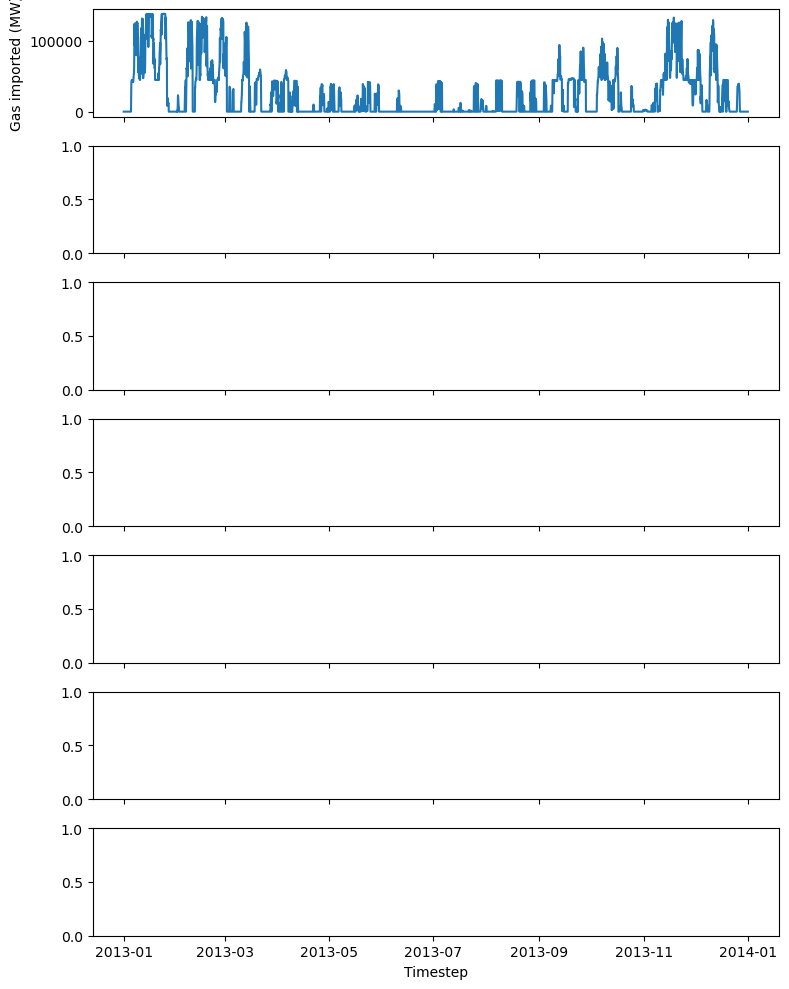

In [ ]:
fig, ax = plt.subplots(7, 1, figsize=(8, 10), sharex=True)

bus = "EU"
gas_imports = n[sample].generators_t["p"][f"{bus} gas"]
ax[0].plot(gas_imports)
ax[0].set_ylabel("Gas imported (MW)")


ax[-1].set_xlabel("Timestep")

plt.tight_layout()

Why is the import of gas behaving as if the cost is some kind of timeseries?

-> Maybe because SMR is converting natural gas into hydrogen!

In [ ]:
n[sample].links.filter(regex="SMR", axis=0)

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_set,p_min_pu,p_max_pu,capital_cost,marginal_cost,marginal_cost_quadratic,stand_by_cost,length,terrain_factor,committable,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus2,efficiency2,efficiency3,reversed,length_original
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [ ]:
# fig, ax = plt.subplots(3, 1, figsize=(8, 8))

# n[sample].generators_t["p"].filter(items=[f"{bus} gas"]).plot(ax=ax[0])
# n[sample].links_t["p0"].filter(items=[f"{bus} SMR CC"]).plot(ax=ax[1])
# n[sample].links_t["p0"].filter(items=[f"{bus} SMR"]).plot(ax=ax[2])

Okay, so there are other things driving the gas demand, this explains how gas can be imported through the generator and look like like it's influenced like a timeseries!

## Static variables
Not dependent on t

### Buses, carriers, generators, lines, links, loads, storage units, and stores

In [ ]:
n[sample].buses.index.tolist()

['DE0 0',
 'EU',
 'co2 atmosphere',
 'DE0 0 co2 stored',
 'DE0 0 co2 sequestered',
 'EU gas',
 'DE0 0 H2',
 'DE0 0 battery',
 'DE0 0 EV battery',
 'DE0 0 low voltage',
 'DE0 0 home battery']

In [ ]:
n[sample].carriers.sort_index().index.to_list()

['',
 'AC',
 'BEV charger',
 'CCGT',
 'DC',
 'EV battery',
 'H2',
 'H2 Electrolysis',
 'OCGT',
 'battery',
 'battery charger',
 'battery discharger',
 'co2',
 'co2 sequestered',
 'co2 stored',
 'electricity',
 'electricity distribution grid',
 'gas',
 'home battery',
 'home battery charger',
 'home battery discharger',
 'land transport EV',
 'load',
 'low voltage',
 'none',
 'offwind-ac',
 'offwind-dc',
 'onwind',
 'solar',
 'solar rooftop',
 'solar-hsat']

In [ ]:
n[sample].generators.sort_index().index.to_list()

['DE0 0 0 offwind-ac',
 'DE0 0 0 offwind-dc',
 'DE0 0 0 onwind',
 'DE0 0 0 solar',
 'DE0 0 0 solar rooftop',
 'DE0 0 0 solar-hsat',
 'DE0 0 EV battery load',
 'DE0 0 H2 load',
 'DE0 0 battery load',
 'DE0 0 co2 sequestered load',
 'DE0 0 co2 stored load',
 'DE0 0 home battery load',
 'DE0 0 load',
 'DE0 0 low voltage load',
 'EU gas',
 'EU gas load',
 'EU load',
 'co2 atmosphere load']

In [ ]:
n[sample].lines.index.tolist()

[]

In [ ]:
n[sample].links.index.tolist()

['DE0 0 co2 sequestered',
 'DE0 0 OCGT',
 'DE0 0 CCGT',
 'DE0 0 H2 Electrolysis',
 'DE0 0 battery charger',
 'DE0 0 battery discharger',
 'DE0 0 BEV charger',
 'DE0 0 electricity distribution grid',
 'DE0 0 home battery charger',
 'DE0 0 home battery discharger',
 'DE0 0 electricity distribution grid-reversed']

In [ ]:
n[sample].loads.index.tolist()

['DE0 0', 'DE0 0 land transport EV']

In [ ]:
n[sample].storage_units.index.tolist()

[]

In [ ]:
n[sample].stores.index.tolist()

['co2 atmosphere',
 'DE0 0 co2 stored',
 'DE0 0 co2 sequestered',
 'EU gas Store',
 'DE0 0 battery',
 'DE0 0 EV battery',
 'DE0 0 home battery']

In [ ]:
n[sample].storage_units["max_hours"]

Series([], Name: max_hours, dtype: float64)

### Transmission

In [ ]:
# for row in n[sample].component_attrs["Line"][["description"]].itertuples():
#     print(f"Line {row.Index}: {row.description}")

In [ ]:
len(n[sample].lines)

0

In [ ]:

print(f"Initial transmission capacity: {n[sample].lines.s_nom} MW")
print(f"Final (optimal) transmission capacity: {n[sample].lines.s_nom_opt} MW")
if len(n[sample].lines) > 0:
    # no lines in a one-node network
    proportional_increase = (n[sample].lines.s_nom_opt.iloc[0] / n[sample].lines.s_nom.iloc[0]) * 100
    print(f"Proportional increase: {proportional_increase}%")

Initial transmission capacity: Series([], Name: s_nom, dtype: float64) MW
Final (optimal) transmission capacity: Series([], Name: s_nom_opt, dtype: float64) MW


### Capacities

#### Generators and storage units

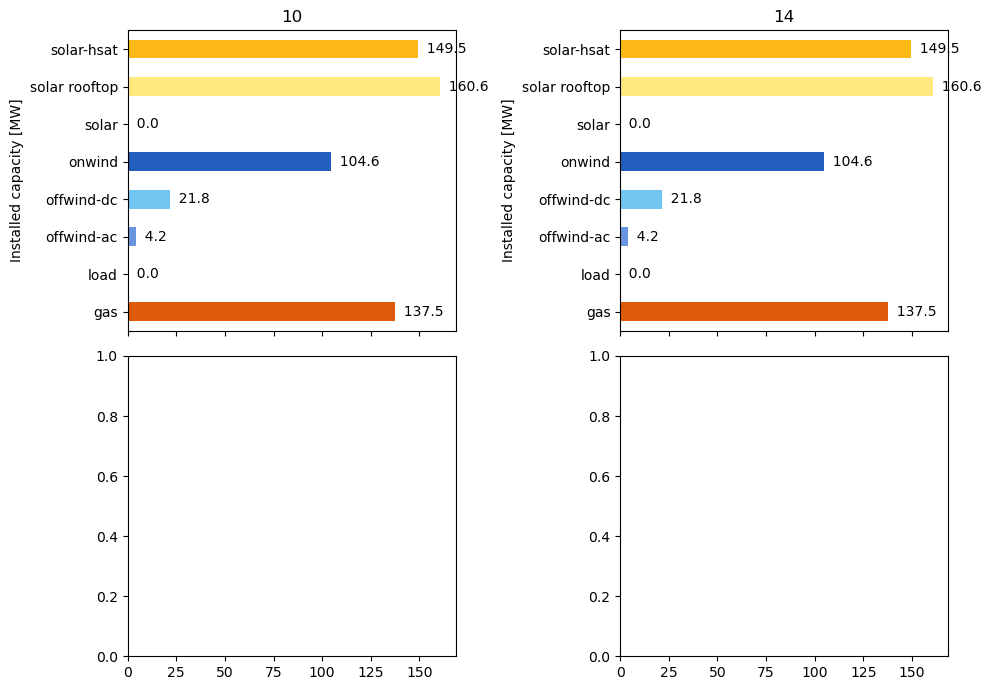

In [ ]:
installed_generators = n[sample].generators.groupby("carrier")["p_nom_opt"].sum().div(1000)  # GW
installed_storage_units = n[sample].storage_units.groupby("carrier")["p_nom_opt"].sum().div(1000)  # GW

fig, ax = plt.subplots(2, len(samples), figsize=(10, 7), sharex=True)

if len(samples) == 1:
    ax = ax[:, None]

for i, s in enumerate(samples):
    # drop_gen = ["load", "solid biomass", "biogas", "curtailment"]
    drop_gen = []
    carriers = installed_generators.drop(drop_gen).index
    colors = [tech_colors.get(carrier, "#888888") for carrier in carriers]
    installed_generators.drop(drop_gen).plot(kind="barh", ax=ax[0, i], color=colors)
    ax[0, i].set_ylabel("Installed capacity [MW]")
    ax[0, i].set_title(f"{s}")
    for j in range(len(installed_generators.drop(drop_gen))):
        value = installed_generators.drop(drop_gen).iloc[j]
        ax[0, i].text(value, j, f"  {value:.1f}", va='center')

    if len(installed_storage_units) == 0:
        continue
    colors = [tech_colors.get(carrier, "#888888") for carrier in installed_storage_units.index]
    installed_storage_units.plot(kind="barh", ax=ax[1, i], color=colors)
    ax[1, i].set_ylabel("Installed capacity [MW]")
    ax[1, i].set_title(f"{s}")
    ax[1, i].set_xlabel("Installed capacity [GW]")

plt.tight_layout()

#### Links and stores

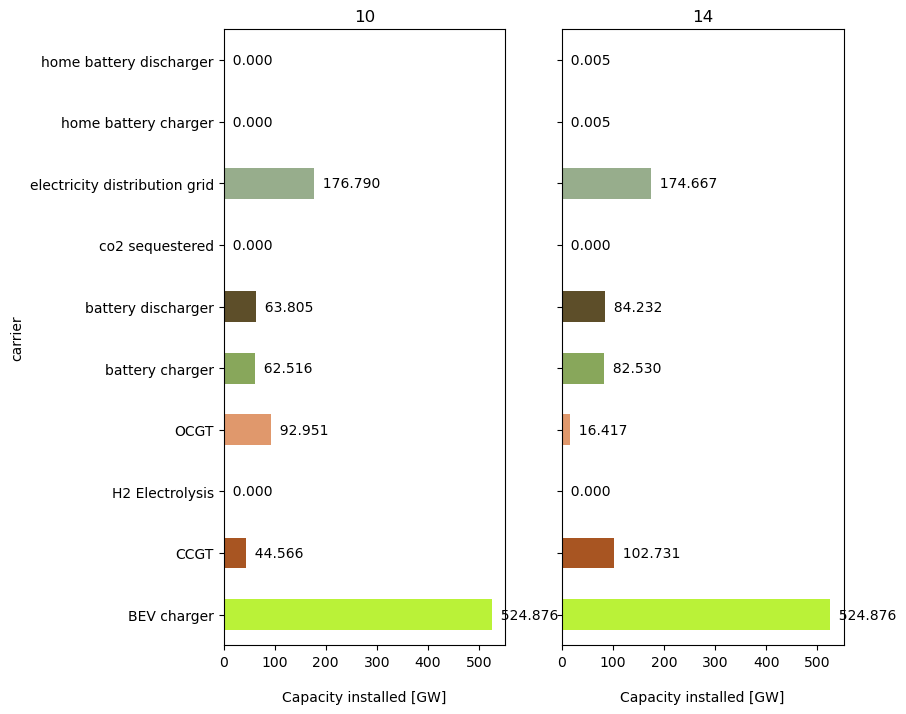

In [ ]:
fig, ax = plt.subplots(1, len(samples), figsize=(8, 8), sharey=True)

drop_links = []

if len(samples) == 1:
    ax = [ax]

installed_links = {}

for i, s in enumerate(samples):
    installed_links[s] = n[s].links.groupby("carrier").sum()["p_nom_opt"].div(1000).drop(drop_links)  # GW
    installed_links[s].plot(kind="barh", ax=ax[i], color=[tech_colors.get(c, "#888888") for c in installed_links[s].index])
    ax[i].set_title(f"{s}")
    ax[i].set_xlabel("Capacity installed [GW]", labelpad=15)
    for j in range(len(installed_links[s])):
        value = installed_links[s].iloc[j]
        ax[i].text(value, j, f"  {value:.3f}", va='center')

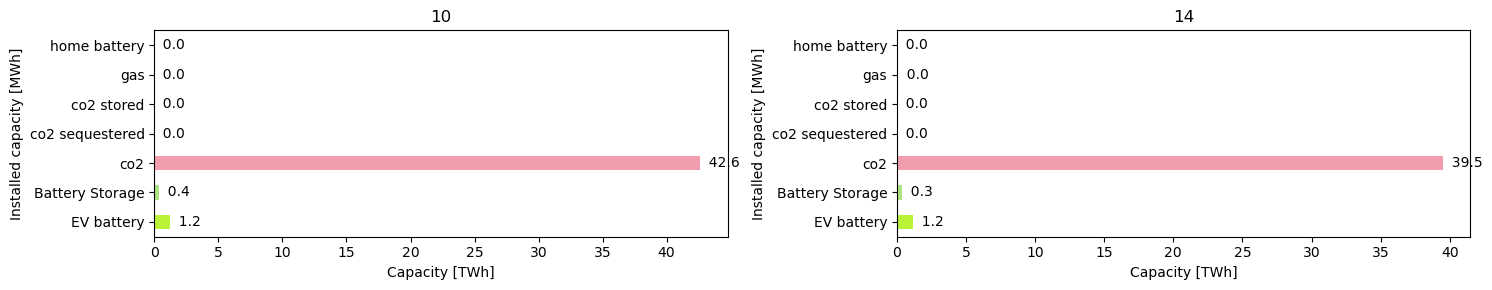

In [ ]:
fig, ax = plt.subplots(1, len(samples), figsize=(15, 3))

if len(samples) == 1:
    ax = [ax]

drop_stores = []
installed_stores = {}

for i, s in enumerate(samples):
    installed_stores[i] = n[s].stores.groupby("carrier")["e_nom_opt"].sum().div(1e6).drop(drop_stores)  # TWh
    colors = [tech_colors.get(carrier, "#888888") for carrier in installed_stores[i].index]
    installed_stores[i].plot(kind="barh", ax=ax[i], color=colors)
    ax[i].set_ylabel("Installed capacity [MWh]")
    ax[i].set_title(f"{s}")
    ax[i].set_yticklabels([nice_names.get(label.get_text(), label.get_text()) for label in ax[i].get_yticklabels()])
    ax[i].set_xlabel("Capacity [TWh]")
    for j in range(len(installed_stores[i])):
        value = installed_stores[i].iloc[j]
        ax[i].text(value, j, f"  {value:.1f}", va='center')
    plt.tight_layout()

### Costs

In [ ]:
time_interval = (
    n[sample].snapshots[1] - n[sample].snapshots[0]
).total_seconds() / 3600  # pyright: ignore[reportOperatorIssue] # hours

n[sample].generators.marginal_cost * n[sample].generators_t.p.sum() * time_interval

name
DE0 0 0 onwind                2.588351e+06
DE0 0 0 offwind-ac            2.275728e+05
DE0 0 0 offwind-dc            1.432444e+06
DE0 0 0 solar-hsat            1.583418e+06
DE0 0 0 solar                 6.743475e-07
EU gas                        5.289260e+09
DE0 0 0 solar rooftop         1.539953e+06
DE0 0 load                    2.833591e-05
EU load                       0.000000e+00
co2 atmosphere load           0.000000e+00
DE0 0 co2 stored load         6.601857e-05
DE0 0 co2 sequestered load    3.267230e-05
EU gas load                   0.000000e+00
DE0 0 H2 load                 0.000000e+00
DE0 0 battery load            2.829014e-05
DE0 0 EV battery load         2.959275e-05
DE0 0 low voltage load        2.827812e-05
DE0 0 home battery load       2.824649e-05
dtype: float64

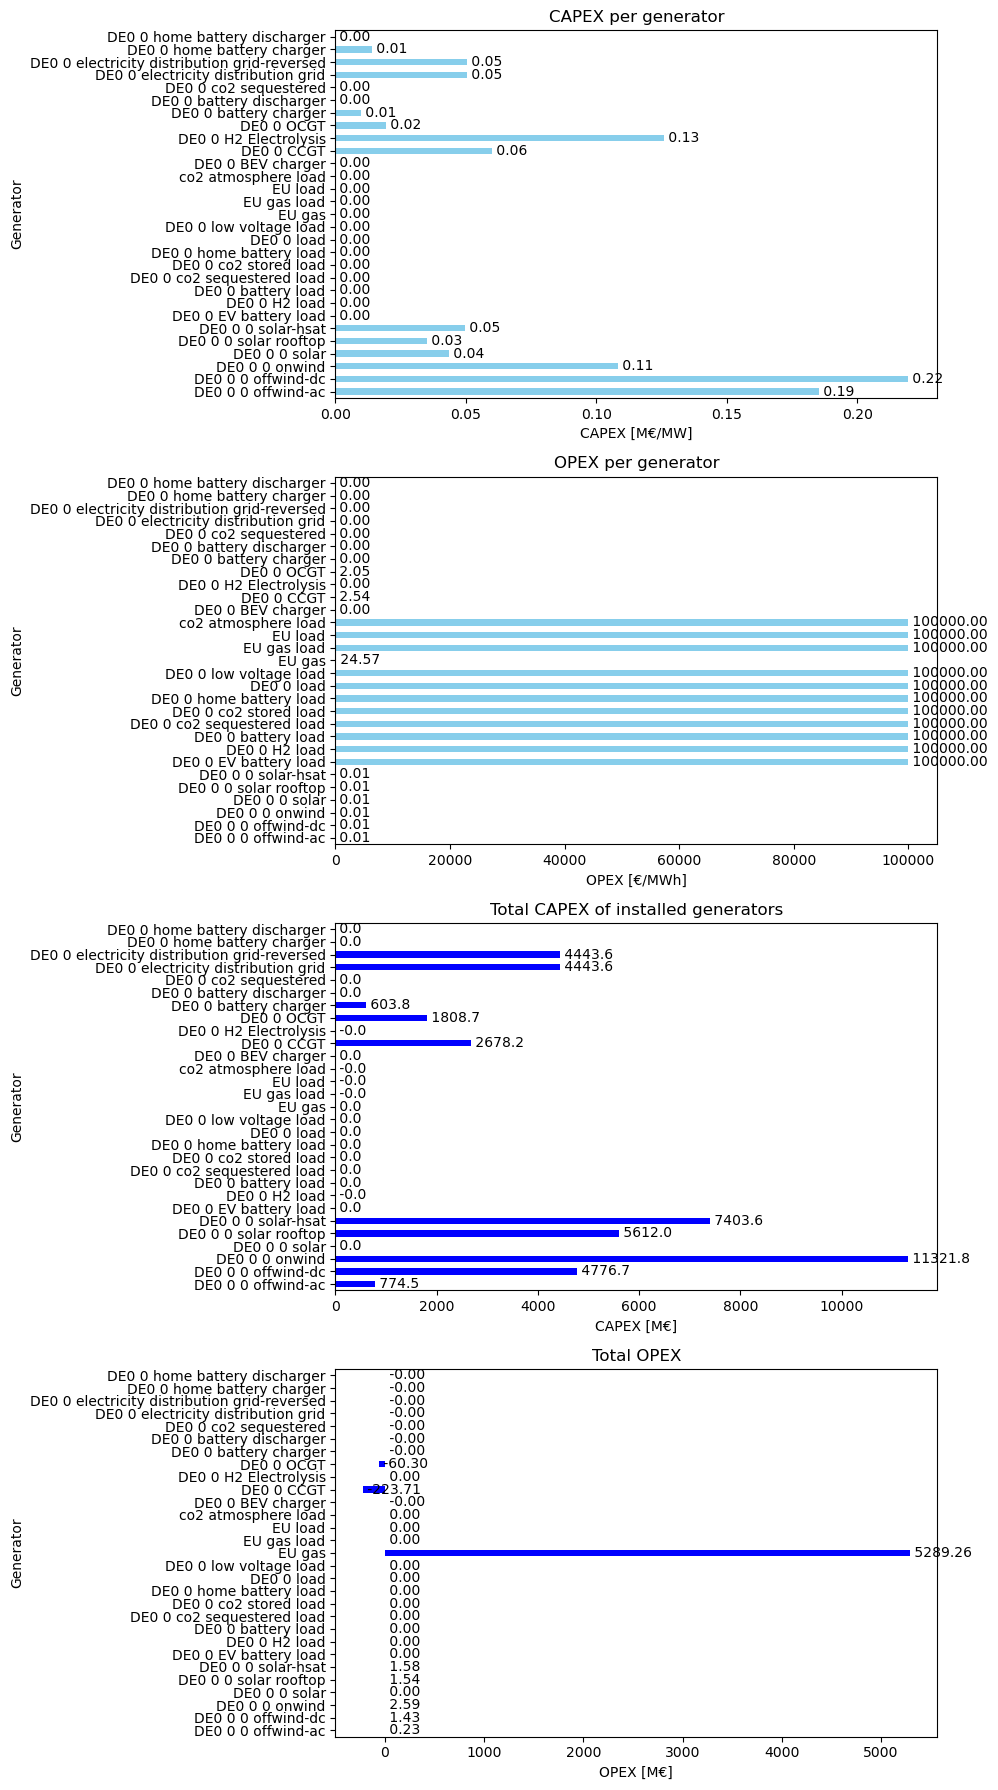

Total Capital Cost: 43.87 billion EUR
Total Operational Cost: 5.2966 billion EUR
Total Cost: 49.16 billion EUR
Objective Function Value: 47.54 billion EUR


In [ ]:
components = ["generators", "links", "storage_units"]

capex_marginal = {}
capital_costs_installed = {}
marginal_costs = {}
marginal_costs_installed = {}

time_interval = (n[sample].snapshots[1] - n[sample].snapshots[0]).total_seconds() / 3600  # pyright: ignore[reportOperatorIssue] # hours

for comp in components:
    capex_marginal[comp] = getattr(n[sample], comp).capital_cost.sort_index().div(1e6)  # M€/MW
    capital_costs_installed[comp] = capex_marginal[comp] * getattr(n[sample], comp)["p_nom_opt"]  # M€
    marginal_costs[comp] = getattr(n[sample], comp).marginal_cost.sort_index()  # €/MWh

    if comp == "links":
        energy_produced = getattr(n[sample], f"{comp}_t")["p1"].sum() * time_interval  # MWh
    else:
        energy_produced = getattr(n[sample], f"{comp}_t")["p"].sum() * time_interval  # MWh
    marginal_costs_installed[comp] = getattr(n[sample], comp).marginal_cost * energy_produced / 1e6  # M€

# concatenate the series and drop multindex
capex_marginal = pd.concat(capex_marginal).sort_index().reset_index(level=0, drop=True)
capital_costs_installed = pd.concat(capital_costs_installed).sort_index().reset_index(level=0, drop=True)
marginal_costs = pd.concat(marginal_costs).sort_index().reset_index(level=0, drop=True)
marginal_costs_installed = pd.concat(marginal_costs_installed).sort_index().reset_index(level=0, drop=True)

fig, ax = plt.subplots(4, 1, figsize=(10, 18))

# barplot of capital costs per generator
capex_marginal.plot(kind="barh", ax=ax[0], title="CAPEX per generator", color="skyblue")
ax[0].set_xlabel("CAPEX [M€/MW]")
ax[0].set_ylabel("Generator")
for j in range(len(capex_marginal)):
    value = capex_marginal.iloc[j]
    ax[0].text(value, j, f" {value:.2f}", va='center')

# barplot of marginal costs per generator
marginal_costs.plot(kind="barh", ax=ax[1], title="OPEX per generator", color="skyblue")
ax[1].set_xlabel("OPEX [€/MWh]")
ax[1].set_ylabel("Generator")
for j in range(len(marginal_costs)):
    value = marginal_costs.iloc[j]
    ax[1].text(value, j, f" {value:.2f}", va="center")

# plot total capital costs of installed generators by multiplying by p_nom_opt
capital_costs_installed.plot(kind="barh", ax=ax[2], title="Total CAPEX of installed generators", color="blue")
ax[2].set_xlabel("CAPEX [M€]")
ax[2].set_ylabel("Generator")
for j in range(len(capital_costs_installed)):
    value = capital_costs_installed.iloc[j]
    ax[2].text(value, j, f" {value:.1f}", va="center")


# barplot of total marginal costs
marginal_costs_installed.plot(kind="barh", ax=ax[3], title="Total OPEX", color="blue")
ax[3].set_xlabel("OPEX [M€]")
ax[3].set_ylabel("Generator")
for j in range(len(marginal_costs_installed)):
    value = marginal_costs_installed.iloc[j]
    ax[3].text(value, j, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()

capex = (
    (n[sample].generators.p_nom_opt * n[sample].generators.capital_cost).sum()
    + (n[sample].links.p_nom_opt * n[sample].links.capital_cost).sum()
    + (n[sample].storage_units.p_nom_opt * n[sample].storage_units.capital_cost).sum()
) / 1e9  # Convert to billion EUR

print(f"Total Capital Cost: {capex:.2f} billion EUR")

opex = (
    (n[sample].generators_t.p * n[sample].generators.marginal_cost).sum().sum()
) / 1e9  # Convert to billion EUR

print(f"Total Operational Cost: {opex:.4f} billion EUR")

total_cost = capex + opex
print(f"Total Cost: {total_cost:.2f} billion EUR")

objective = n[sample].objective / 1e9  # Convert to billion EUR
print(f"Objective Function Value: {objective:.2f} billion EUR")

## Dynamic variables


### Total energy

#### Loads

/var/folders/cd/3symzw7d0833vd8qj4shbrl80000gp/T/ipykernel_87183/3151958676.py:4: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



Text(0, 0.5, 'Carrier')

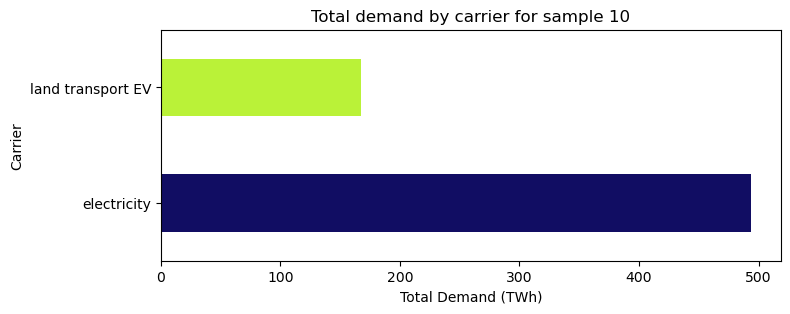

In [ ]:
# Plot total demand by carrier as horizontal bar charts
fig, ax = plt.subplots(figsize=(8, 3))

demand_p_by_carrier = n[sample].loads_t.p.groupby(n[sample].loads["carrier"], axis=1).sum()  # MW
total_demand = demand_p_by_carrier.sum() * time_interval / 1e6  # TWh
carriers = total_demand.index
colors = [tech_colors.get(carrier, "#888888") for carrier in carriers]
total_demand.plot(kind="barh", ax=ax, color=colors)
ax.set_title(f"Total demand by carrier for sample {sample}")
ax.set_xlabel("Total Demand (TWh)")
ax.set_ylabel("Carrier")

#### Generators and storage units

In [ ]:
load_shed_generator_elec = n[sample].buses[n[sample].buses["carrier"] == "AC"].index + " load"
load_shed_generators = n[sample].generators[n[sample].generators["carrier"] == "load"].index
n[sample].generators_t["p"][load_shed_generators].sum()

# n[sample].generators_t["p"][load_shed_generator_elec].sum().sum() * time_interval / 1e3  # GWh

name
DE0 0 load                    2.833591e-10
EU load                       0.000000e+00
co2 atmosphere load           0.000000e+00
DE0 0 co2 stored load         6.601857e-10
DE0 0 co2 sequestered load    3.267230e-10
EU gas load                   0.000000e+00
DE0 0 H2 load                 0.000000e+00
DE0 0 battery load            2.829014e-10
DE0 0 EV battery load         2.959275e-10
DE0 0 low voltage load        2.827812e-10
DE0 0 home battery load       2.824649e-10
dtype: float64

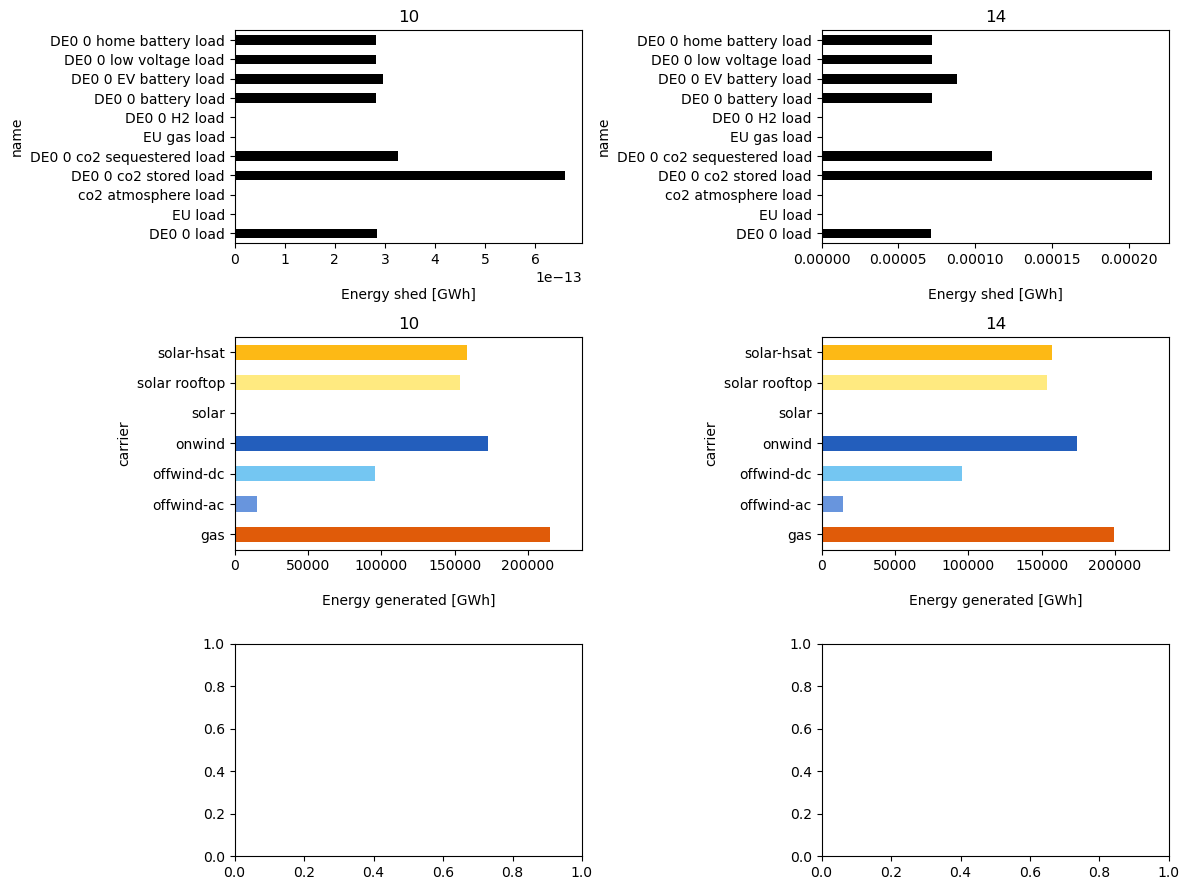

In [ ]:
# Plot total energy generated by both generators and storage units by carrier as bar charts with shared x-axis
fig, ax = plt.subplots(3, len(samples), figsize=(12, 9), squeeze=False)

# drop_gen = ["load", "solid biomass", "biogas", "curtailment"]
drop_gen = ["load"]

# Find the maximum value across all samples to set consistent scale
max_values = []
for s in samples:
    gen_p_by_carrier = n[s].generators_t["p"].T.groupby(n[s].generators["carrier"]).sum().T  # MW
    energy_generated = gen_p_by_carrier.sum() * time_interval / 1e3  # Convert to GWh
    max_values.append(energy_generated.drop(drop_gen).max())

max_xlim = max(max_values) * 1.1  # Add 10% padding

for i, s in enumerate(samples):
    # Plot load shed
    load_shed_generators = n[s].generators[n[s].generators["carrier"] == "load"].index
    load_shed_by_generator = n[s].generators_t["p"][load_shed_generators].sum() * time_interval / 1e3  # GWh
    colors = ["#000000"]  # Use a distinct color for load shedding
    load_shed_by_generator.plot(kind="barh", ax=ax[0, i], color=colors)
    ax[0, i].set_xlabel("Energy shed [GWh]", labelpad=15)
    ax[0, i].set_title(f"{s}")
    # ax[0, i].set_xlim(0, max_xlim)  # Set consistent x-axis limits

    # Plot energy generated by generators
    gen_p_by_carrier = n[s].generators_t["p"].T.groupby(n[s].generators["carrier"]).sum().T  # MW
    energy_generated = gen_p_by_carrier.sum() * time_interval / 1e3  # Convert to GWh
    carriers = energy_generated.drop(drop_gen).index
    colors = [tech_colors.get(carrier, "#888888") for carrier in carriers]
    energy_generated.drop(drop_gen).plot(kind="barh", ax=ax[1, i], color=colors)
    ax[1, i].set_xlabel("Energy generated [GWh]", labelpad=15)
    ax[1, i].set_title(f"{s}")
    ax[1, i].set_xlim(0, max_xlim)  # Set consistent x-axis limits

    # Now plot total energy discharged from storage units
    if len(n[sample].storage_units) == 0:
        continue
    su_p_by_carrier = n[s].storage_units_t["p"].T.groupby(n[s].storage_units["carrier"]).sum().T  # MW
    energy_discharged = su_p_by_carrier[su_p_by_carrier < 0].sum() * time_interval / 1e3  # Convert to GWh
    carriers = energy_discharged.index
    colors = [tech_colors.get(carrier, "#888888") for carrier in carriers]
    energy_discharged.plot(kind="barh", ax=ax[2, i], color=colors)
    ax[2, i].set_xlabel("Energy discharged [GWh]", labelpad=15)
    ax[2, i].set_title(f"{s}")
    ax[2, i].set_xlim(0, max_xlim)  # Set consistent x-axis limits

plt.tight_layout()

#### Links and stores

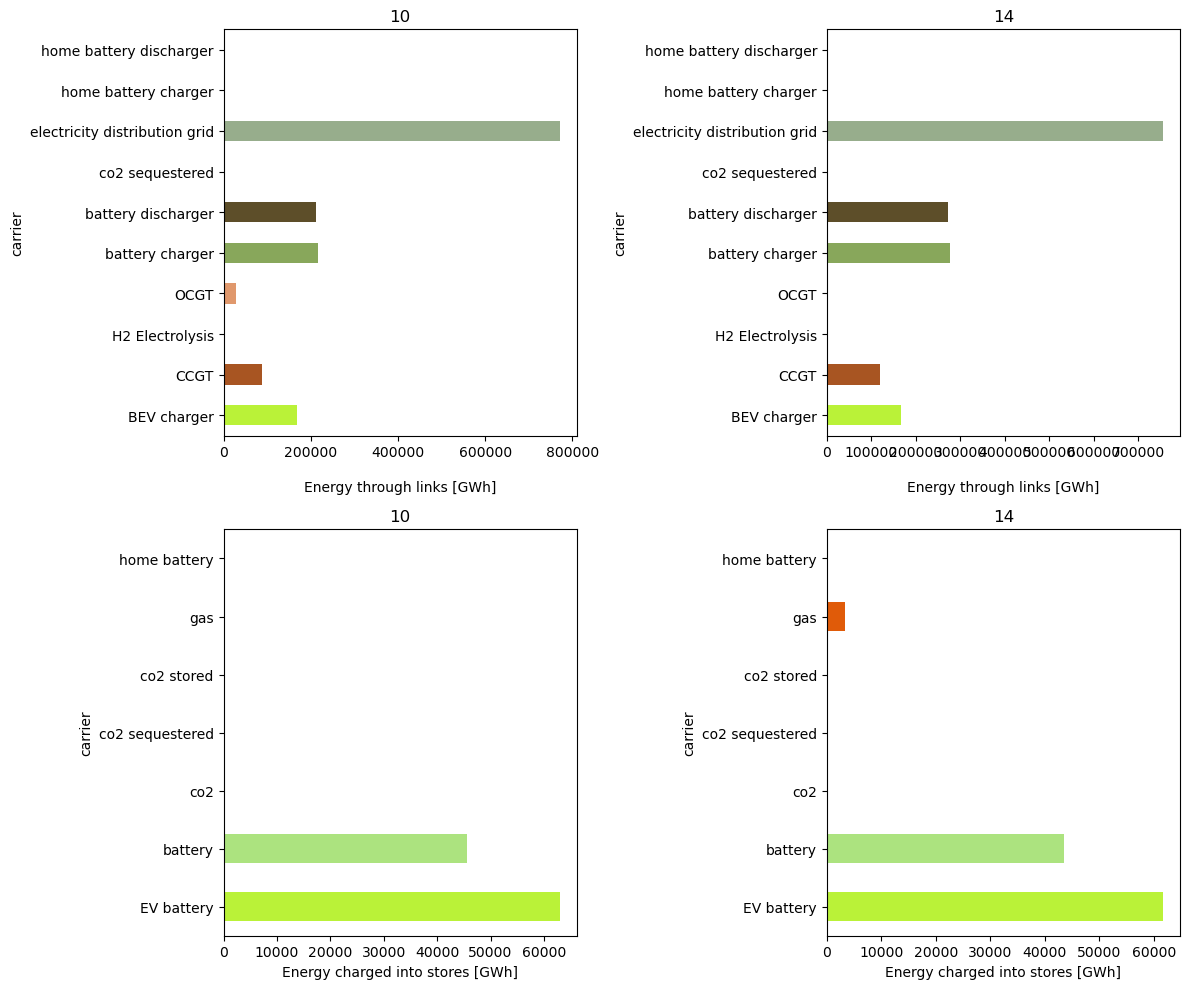

In [ ]:
# plot total energy through links by carrier as horizontal bar charts, as well as total energy charged into stores
fig, ax = plt.subplots(2, len(samples), figsize=(12, 10), squeeze=False)

energy_released_from_stores = {}
energy_through_links = {}
for i, s in enumerate(samples):
    # Total energy through links by carrier
    link_p_by_carrier = n[s].links_t.p1.T.groupby(n[s].links.carrier).sum().T  # MW
    energy_through_links[s] = link_p_by_carrier.abs().sum() * time_interval / 1e3  # Convert to GWh
    carriers = energy_through_links[s].index
    colors = [tech_colors.get(carrier, "#888888") for carrier in carriers]
    energy_through_links[s].plot(kind="barh", ax=ax[0, i], color=colors)
    ax[0, i].set_xlabel("Energy through links [GWh]", labelpad=15)
    ax[0, i].set_title(f"{s}")

    # Total energy charged into stores
    store_p_by_carrier = n[s].stores_t.p.T.groupby(n[s].stores.carrier).sum().T  # MW
    energy_released_from_stores[s] = store_p_by_carrier[store_p_by_carrier > 0].sum() * time_interval / 1e3  # Convert to GWh
    carriers = energy_released_from_stores[s].index
    colors = [tech_colors.get(carrier, "#888888") for carrier in carriers]
    energy_released_from_stores[s].plot(kind="barh", ax=ax[1, i], color=colors)
    ax[1, i].set_xlabel("Energy charged into stores [GWh]")
    ax[1, i].set_title(f"{s}")

plt.tight_layout()

In [ ]:
energy_through_links

{'10': carrier
 BEV charger                      1.678510e+05
 CCGT                             8.808422e+04
 H2 Electrolysis                  0.000000e+00
 OCGT                             2.944794e+04
 battery charger                  2.169183e+05
 battery discharger               2.125357e+05
 co2 sequestered                  6.601858e-13
 electricity distribution grid    7.712429e+05
 home battery charger             6.809337e-08
 home battery discharger          6.671788e-08
 dtype: float64,
 '14': carrier
 BEV charger                      167850.993184
 CCGT                             119034.531858
 H2 Electrolysis                       0.000000
 OCGT                                471.954718
 battery charger                  276990.500963
 battery discharger               271394.156453
 co2 sequestered                       0.000215
 electricity distribution grid    755759.482851
 home battery charger                 18.774408
 home battery discharger              18.395158
 dt

### Timeseries

#### Loads

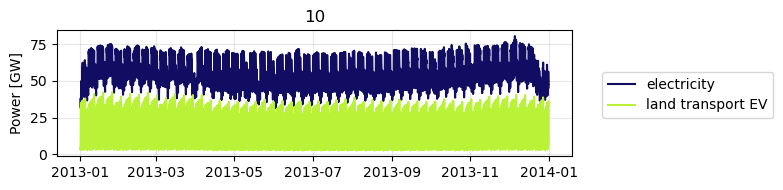

In [ ]:
# Plot time series of load by carrier
fig, ax = plt.subplots(1, figsize=(6, 2), sharex=True)

# Get load time series by carrier
load_p_by_carrier = n[sample].loads_t.p.T.groupby(n[sample].loads.carrier).sum().T / 1e3  # Convert to GW

# Drop certain carriers for cleaner visualization
drop_gen = ["load", "curtailment"]
load_p_by_carrier_clean = load_p_by_carrier.drop(columns=drop_gen, errors="ignore")

# Plot with colors
for carrier in load_p_by_carrier_clean.columns:
    color = tech_colors.get(carrier, "#888888")
    label = nice_names.get(carrier, carrier)
    ax.plot(
        load_p_by_carrier_clean.index,
        load_p_by_carrier_clean[carrier],
        label=label,
        color=color,
    )

ax.set_title(f"{sample}")
ax.set_ylabel("Power [GW]")
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#### Generators

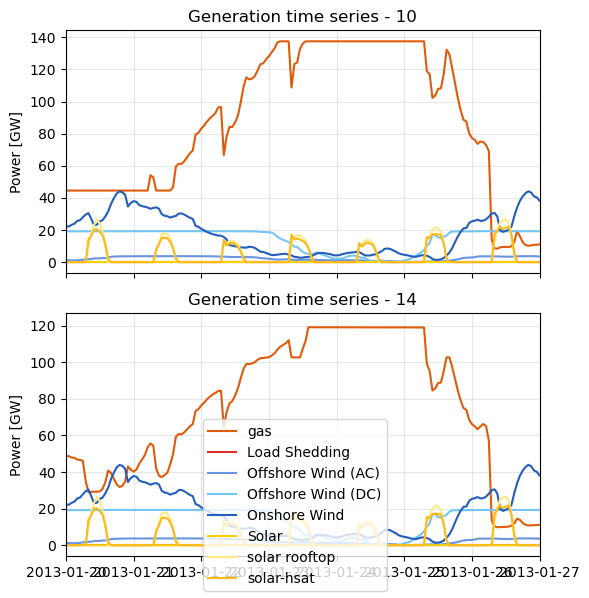

In [ ]:
# Plot time series of generation by carrier
fig, ax = plt.subplots(len(samples), 1, figsize=(6, 6), sharex=True)
if len(samples) == 1:
    ax = [ax]

for i, s in enumerate(samples):
    # Get generation time series by carrier
    gen_p_by_carrier = n[s].generators_t.p.T.groupby(n[s].generators.carrier).sum().T / 1e3  # Convert to GW

    # Drop certain carriers for cleaner visualization
    # drop_gen = ["load", "curtailment"]
    drop_gen = []
    gen_p_by_carrier_clean = gen_p_by_carrier.drop(columns=drop_gen, errors='ignore')

    # Plot with colors
    for carrier in gen_p_by_carrier_clean.columns:
        color = tech_colors.get(carrier, "#888888")
        label = nice_names.get(carrier, carrier)
        ax[i].plot(gen_p_by_carrier_clean.index, gen_p_by_carrier_clean[carrier],
                  label=label, color=color)

    ax[i].set_title(f"Generation time series - {s}")
    ax[i].set_ylabel("Power [GW]")
    ax[i].grid(True, alpha=0.3)
    ax[0].set_xlim(pd.Timestamp("2013-01-20"), pd.Timestamp("2013-01-27"))

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center")
# limit x-axis to one week for visibility
plt.tight_layout()

#### Storage units

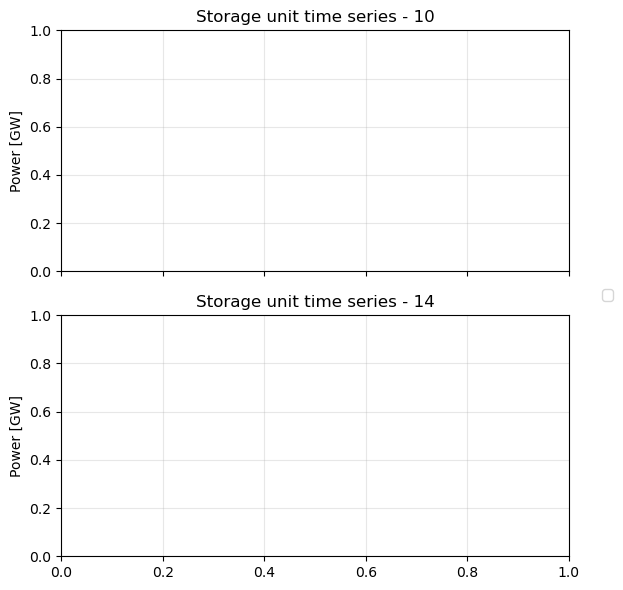

In [ ]:
# Plot time series of generation of storage unit by carrier
fig, ax = plt.subplots(len(samples), 1, figsize=(6, 6), sharex=True)
if len(samples) == 1:
    ax = [ax]

for i, s in enumerate(samples):
    # Get generation time series by carrier
    gen_p_by_carrier = (
        n[s].storage_units_t.p.T.groupby(n[s].storage_units.carrier).sum().T / 1e3
    )  # Convert to GW

    # Plot with colors
    for carrier in gen_p_by_carrier.columns:
        color = tech_colors.get(carrier, "#888888")
        label = nice_names.get(carrier, carrier)
        ax[i].plot(
            gen_p_by_carrier.index,
            gen_p_by_carrier[carrier],
            label=label,
            color=color,
        )

    ax[i].set_title(f"Storage unit time series - {s}")
    ax[i].set_ylabel("Power [GW]")
    ax[i].grid(True, alpha=0.3)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#### Stores

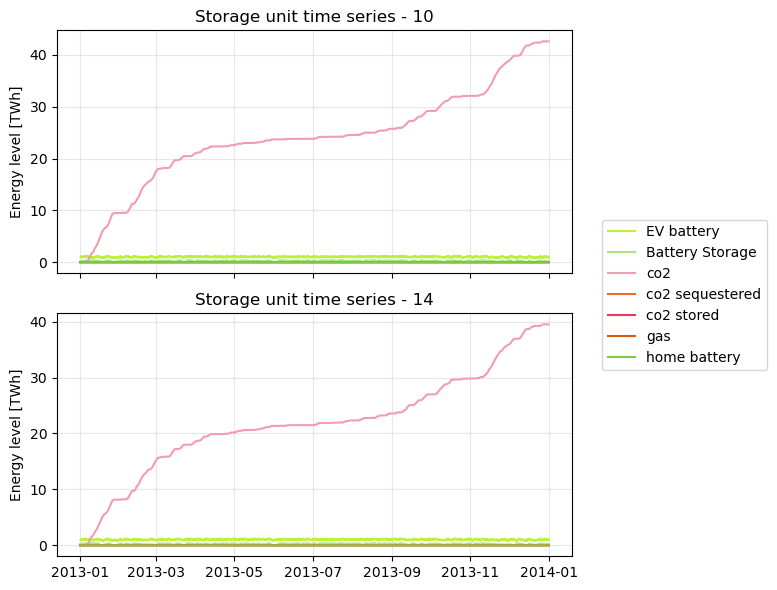

In [ ]:
# Plot time series of stores energy level by carrier
fig, ax = plt.subplots(len(samples), 1, figsize=(6, 6), sharex=True)
if len(samples) == 1:
    ax = [ax]

for i, s in enumerate(samples):
    # Get generation time series by carrier
    gen_p_by_carrier = n[s].stores_t.e.T.groupby(n[s].stores.carrier).sum().T / 1e6  # Convert to TWh

    # Plot with colors
    for carrier in gen_p_by_carrier.columns:
        color = tech_colors.get(carrier, "#888888")
        label = nice_names.get(carrier, carrier)
        ax[i].plot(
            gen_p_by_carrier.index,
            gen_p_by_carrier[carrier],
            label=label,
            color=color,
        )

    ax[i].set_title(f"Storage unit time series - {s}")
    ax[i].set_ylabel("Energy level [TWh]")
    ax[i].grid(True, alpha=0.3)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

#### Links

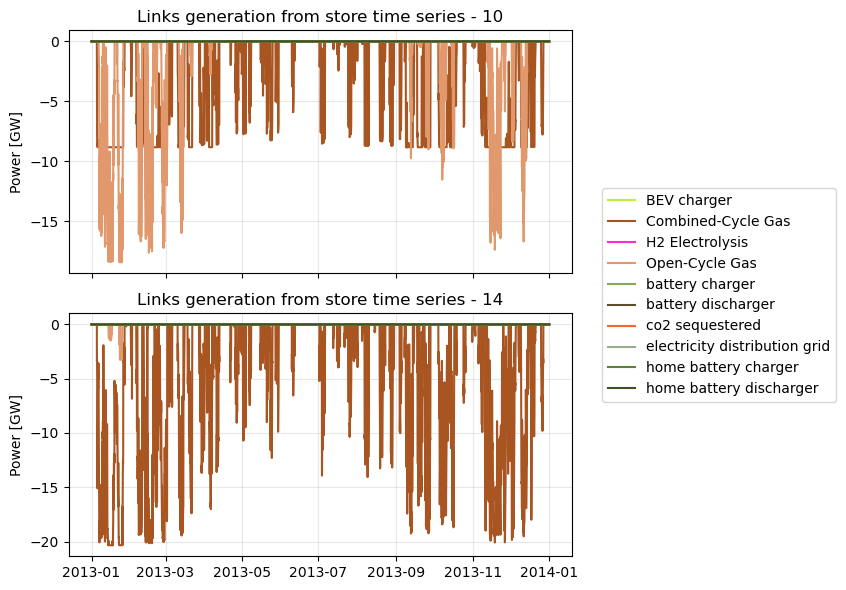

In [ ]:
# Plot time series of generation of links by carrier
fig, ax = plt.subplots(len(samples), 1, figsize=(6, 6), sharex=True)
if len(samples) == 1:
    ax = [ax]

drop_links = []

for i, s in enumerate(samples):
    # Get generation time series by carrier
    gen_p_by_carrier = (
        n[s].links_t.p2.T.groupby(n[s].links.carrier).sum().T.drop(drop_links, axis=1) / 1e3
    )  # Convert to GW

    # Plot with colors
    for carrier in gen_p_by_carrier.columns:
        color = tech_colors.get(carrier, "#888888")
        label = nice_names.get(carrier, carrier)
        ax[i].plot(
            gen_p_by_carrier.index,
            gen_p_by_carrier[carrier],
            label=label,
            color=color,
        )

    ax[i].set_title(f"Links generation from store time series - {s}")
    ax[i].set_ylabel("Power [GW]")
    ax[i].grid(True, alpha=0.3)
2
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()